# OpenCV (Python) — Complete Tutorial Notebook

A hands-on, runnable companion to the OpenCV cheat sheets — every function demonstrated on real, generated images with visible output, plus extra examples (masking, feature matching, uneven-lighting thresholding, a full detection pipeline) that go beyond a typical quick-reference sheet.

**How this notebook is built:** every image you see is generated in code (gradients, shapes, a checkerboard, textured patterns, a tiny video) using NumPy and OpenCV's own drawing functions. That means the whole notebook runs top-to-bottom with no external files or downloads, and you can immediately swap in your own photos wherever you see `scene_img`, `shapes_img`, etc.

## Contents
1. Setup & Imports
2. Generating Synthetic Sample Images
3. Reading, Writing & Displaying Images
4. Image Properties & NumPy Fundamentals
5. Resizing, Cropping, Flipping, Rotating
6. Color Spaces & Channel Operations
7. Drawing Functions
8. Arithmetic & Bitwise Operations (+ color masking)
9. Blurring & Smoothing (Filtering)
10. Thresholding (Simple, Otsu, Adaptive)
11. Morphological Operations
12. Edge Detection (Sobel, Laplacian, Canny)
13. Contours & Shape Classification
14. Histograms & Equalization
15. Geometric Transformations (Affine & Perspective)
16. Feature Detection (ORB, SIFT, AKAZE, BRISK)
17. Feature Matching (BF, KNN, Ratio Test)
18. Template Matching
19. Hough Transforms (Lines & Circles)
20. Object Detection with Haar Cascades
21. Video I/O (Writing & Reading Video)
22. Camera Calibration Basics
23. Capstone: A Complete Shape-Detection Pipeline
24. Quick-Reference Summary
25. Next Steps & Resources

## 1. Setup & Imports

The only two imports you need for 90% of OpenCV work are `cv2` and `numpy` — every image in OpenCV *is* a NumPy array, which is why the two libraries are inseparable. `matplotlib` is added here purely for **displaying** images inline, since `cv2.imshow()` opens a native OS window and does not work inside Jupyter (see the note in Section 3).

In [5]:
%matplotlib inline
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)
print("Install command (if needed): pip install opencv-contrib-python numpy matplotlib")

OpenCV version: 4.13.0
NumPy version: 2.5.1
Install command (if needed): pip install opencv-contrib-python numpy matplotlib


### Display helpers

OpenCV stores color images as **BGR**, not RGB, and has no native way to render inline inside a notebook. These three small helpers are used throughout the rest of the notebook — write them once, reuse everywhere (the same principle as OpenCV's own `cv2.imshow`, just adapted for Jupyter).

In [6]:
def show(img, title="Image", figsize=(5, 5), cmap=None):
    """Display a single BGR (3-channel) or grayscale (2D) image inline."""
    plt.figure(figsize=figsize)
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap or "gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_grid(images, titles=None, cols=3, figsize=None):
    """Display a list of BGR/grayscale images side by side in a grid."""
    n = len(images)
    cols = min(cols, n)
    rows = (n + cols - 1) // cols
    if figsize is None:
        figsize = (4 * cols, 3.6 * rows)
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        if img.ndim == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if titles:
            plt.title(titles[i], fontsize=10)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


def show_channels(multichannel_img, channel_names, label):
    """Display each channel of a non-BGR image (HSV/LAB/YCrCb) as grayscale."""
    plt.figure(figsize=(4 * len(channel_names), 3.6))
    for i, name in enumerate(channel_names):
        plt.subplot(1, len(channel_names), i + 1)
        plt.imshow(multichannel_img[:, :, i], cmap="gray")
        plt.title(f"{label}: {name}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

print("Display helpers ready: show(), show_grid(), show_channels()")

Display helpers ready: show(), show_grid(), show_channels()


## 2. Generating Synthetic Sample Images

Rather than depending on downloaded photos (licensing, availability, reproducibility issues), every test image in this notebook is generated programmatically. This has a nice side effect: the exact same demos work identically for you, offline, forever.

We create five base images, each built for the section that needs it:
- **`scene_img`** — a colorful gradient background with several solid shapes → color, arithmetic, masking, geometric transforms
- **`shapes_img`** — plain background with 6 well-separated flat shapes → thresholding, contours, shape classification
- **`checkerboard_img`** — a synthetic chessboard → camera calibration
- **`lines_circles_img`** — straight lines and circle outlines → Hough transforms
- **`textured_img` / `textured_warped_img`** — a scattered-shape pattern and a rotated+scaled copy of it → feature detection & matching

Feel free to replace any of these with `cv2.imread('your_photo.jpg')` — every downstream cell works the same way on a real photo.

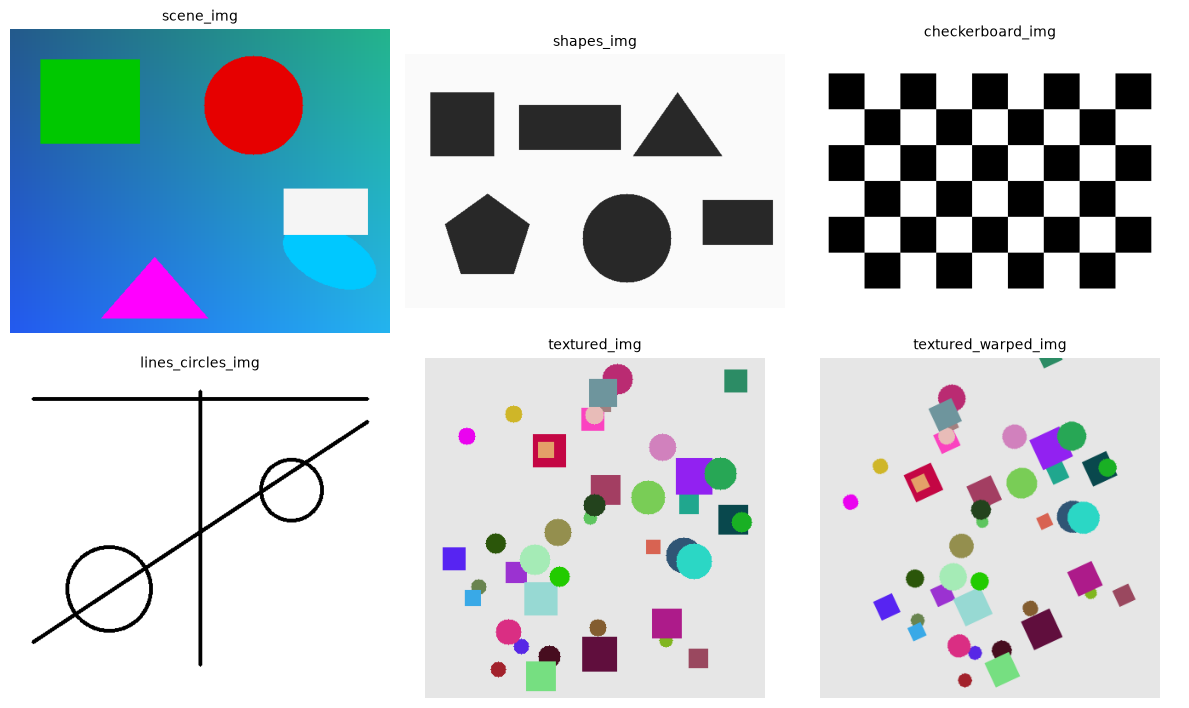

In [7]:
def make_scene_image(w=500, h=400):
    """Cool blue/teal gradient background with several colored solid shapes."""
    yy, xx = np.mgrid[0:h, 0:w]
    b = (140 + 100 * yy / (h - 1)).astype(np.uint8)
    g = (90 + 90 * xx / (w - 1)).astype(np.uint8)
    r = np.full((h, w), 35, dtype=np.uint8)
    img = np.dstack([b, g, r]).copy()

    cv2.rectangle(img, (40, 40), (170, 150), (0, 200, 0), -1)          # green square
    cv2.circle(img, (320, 100), 65, (0, 0, 230), -1)                    # red circle
    cv2.ellipse(img, (420, 300), (65, 35), 25, 0, 360, (255, 200, 0), -1)  # cyan ellipse
    pts = np.array([[190, 300], [260, 380], [120, 380]], np.int32)
    cv2.fillPoly(img, [pts], (255, 0, 255))                             # magenta triangle
    cv2.rectangle(img, (360, 210), (470, 270), (245, 245, 245), -1)     # near-white rect
    return img


def make_shapes_image(w=600, h=400):
    """Plain light background with distinct dark shapes, for threshold/contour demos."""
    img = np.full((h, w, 3), 250, dtype=np.uint8)
    color = (40, 40, 40)
    cv2.rectangle(img, (40, 60), (140, 160), color, -1)                 # square
    cv2.rectangle(img, (180, 80), (340, 150), color, -1)                # rectangle
    tri = np.array([[430, 60], [500, 160], [360, 160]], np.int32)
    cv2.fillPoly(img, [tri], color)                                     # triangle
    cx, cy, r = 130, 290, 70
    pent = np.array([[cx + r * np.cos(a), cy + r * np.sin(a)]
                      for a in np.linspace(-np.pi / 2, 3 * np.pi / 2, 6)[:-1]], np.int32)
    cv2.fillPoly(img, [pent], color)                                    # pentagon
    cv2.circle(img, (350, 290), 70, color, -1)                          # circle
    cv2.rectangle(img, (470, 230), (580, 300), color, -1)               # rectangle 2
    return img


def make_checkerboard(rows=6, cols=9, square=50, margin=40):
    """Synthetic chessboard for corner detection / calibration demos."""
    h, w = rows * square + 2 * margin, cols * square + 2 * margin
    img = np.full((h, w), 255, dtype=np.uint8)
    for rr in range(rows):
        for cc in range(cols):
            if (rr + cc) % 2 == 0:
                y0, y1 = margin + rr * square, margin + (rr + 1) * square
                x0, x1 = margin + cc * square, margin + (cc + 1) * square
                img[y0:y1, x0:x1] = 0
    return img


def make_lines_circles_image(w=500, h=400):
    """Straight lines and circle outlines, for Hough transform demos."""
    img = np.full((h, w), 255, dtype=np.uint8)
    cv2.line(img, (30, 350), (470, 60), 0, 3)
    cv2.line(img, (30, 30), (470, 30), 0, 3)
    cv2.line(img, (250, 20), (250, 380), 0, 3)
    cv2.circle(img, (130, 280), 55, 0, 3)
    cv2.circle(img, (370, 150), 40, 0, 3)
    return img


def make_textured_image(w=400, h=400, n=45, seed=0):
    """Scattered random shapes -> gives feature detectors plenty of corners/blobs."""
    rng = np.random.RandomState(seed)
    img = np.full((h, w, 3), 230, dtype=np.uint8)
    for _ in range(n):
        x, y = rng.randint(25, w - 25), rng.randint(25, h - 25)
        size = rng.randint(8, 22)
        color = tuple(int(c) for c in rng.randint(0, 255, 3))
        if rng.rand() < 0.5:
            cv2.circle(img, (x, y), size, color, -1)
        else:
            cv2.rectangle(img, (x - size, y - size), (x + size, y + size), color, -1)
    return img


# Build every base image once; reused throughout the notebook
scene_img = make_scene_image()
shapes_img = make_shapes_image()
checkerboard_img = make_checkerboard()
lines_circles_img = make_lines_circles_image()

textured_img = make_textured_image(seed=0)
_h, _w = textured_img.shape[:2]
_M_rot = cv2.getRotationMatrix2D((_w / 2, _h / 2), 25, 0.9)
textured_warped_img = cv2.warpAffine(textured_img, _M_rot, (_w, _h), borderValue=(230, 230, 230))

show_grid(
    [scene_img, shapes_img, checkerboard_img, lines_circles_img, textured_img, textured_warped_img],
    ["scene_img", "shapes_img", "checkerboard_img", "lines_circles_img", "textured_img", "textured_warped_img"],
    cols=3,
)

## 3. Reading, Writing & Displaying Images

| Task | Function |
|---|---|
| Read color image | `cv2.imread('image.jpg')` |
| Read grayscale | `cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)` |
| Read with alpha channel | `cv2.imread('image.png', cv2.IMREAD_UNCHANGED)` |
| Save image | `cv2.imwrite('out.jpg', img)` |
| Display (script) | `cv2.imshow('win', img)` then `cv2.waitKey(0)` |

> ⚠️ **The single biggest Jupyter gotcha:** `cv2.imshow()` tries to open a native GUI window. In a notebook (or any headless server) there is no window to open — it will hang, error, or silently do nothing depending on your platform. **Use `matplotlib` (our `show()` helper) inside notebooks**, and reserve `cv2.imshow` / `cv2.waitKey` / `cv2.destroyAllWindows` for standalone `.py` scripts, exactly as shown commented out below.

In [8]:
cv2.imwrite("/tmp/scene.jpg", scene_img)
reloaded_color = cv2.imread("/tmp/scene.jpg")
reloaded_gray = cv2.imread("/tmp/scene.jpg", cv2.IMREAD_GRAYSCALE)
reloaded_unchanged = cv2.imread("/tmp/scene.jpg", cv2.IMREAD_UNCHANGED)

print("Color   :", reloaded_color.shape, reloaded_color.dtype)
print("Grayscale:", reloaded_gray.shape, reloaded_gray.dtype)

show_grid([reloaded_color, reloaded_gray], ["imread (color, BGR)", "imread (IMREAD_GRAYSCALE)"])

# --- Script-only pattern (does NOT work in Jupyter — for reference) ---
# cv2.imshow('Image', reloaded_color)
# cv2.waitKey(0)          # 0 = wait forever for a keypress; 1 = wait 1ms (use in video loops)
# cv2.destroyAllWindows()

AttributeError: 'NoneType' object has no attribute 'shape'

## 4. Image Properties & NumPy Fundamentals

Every OpenCV image is just a NumPy array, so all of NumPy's indexing, slicing, and math apply directly.

| Property | Access |
|---|---|
| Shape `(h, w, channels)` | `img.shape` |
| Height / Width / Channels | `img.shape[0]` / `[1]` / `[2]` |
| Data type (usually `uint8`) | `img.dtype` |
| Total pixel count | `img.size` |
| Single pixel `[B, G, R]` | `img[y, x]` |
| Region of interest (ROI) | `img[y1:y2, x1:x2]` |

Shape (h, w, c): (400, 500, 3)
Height: 400  Width: 500  Channels: 3
Data type: uint8
Total values (size): 600000
Pixel at (100, 200) [B, G, R]: [165 126  35]
ROI shape: (110, 130, 3)


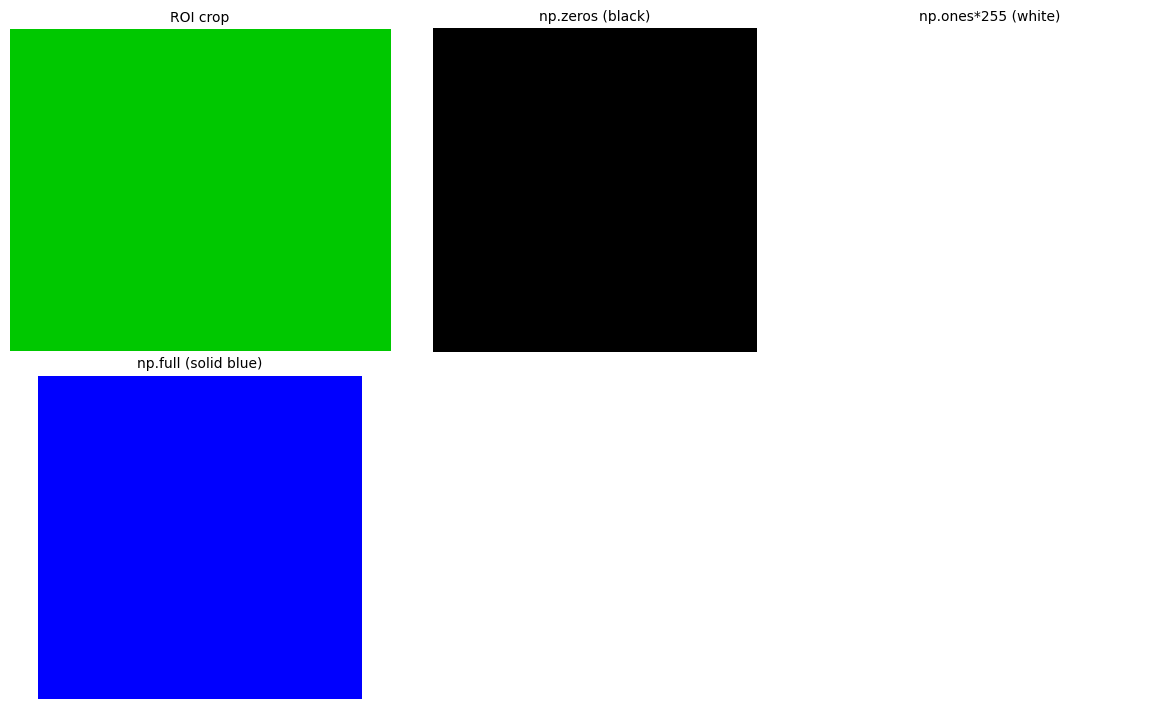

In [ ]:
print("Shape (h, w, c):", scene_img.shape)
print("Height:", scene_img.shape[0], " Width:", scene_img.shape[1], " Channels:", scene_img.shape[2])
print("Data type:", scene_img.dtype)
print("Total values (size):", scene_img.size)
print("Pixel at (100, 200) [B, G, R]:", scene_img[100, 200])

roi = scene_img[40:150, 40:170]           # slicing = ROI, no copy is made unless you call .copy()
print("ROI shape:", roi.shape)

blank = np.zeros((200, 200, 3), np.uint8)         # all-black canvas
white = np.ones((200, 200, 3), np.uint8) * 255    # all-white canvas
solid_blue = np.full((200, 200, 3), (255, 0, 0), np.uint8)  # solid color canvas (BGR!)
show_grid([roi, blank, white, solid_blue], ["ROI crop", "np.zeros (black)", "np.ones*255 (white)", "np.full (solid blue)"])

## 5. Resizing, Cropping, Flipping, Rotating

| Task | Function |
|---|---|
| Resize to exact size | `cv2.resize(img, (w, h))` |
| Resize by scale factor | `cv2.resize(img, None, fx=0.5, fy=0.5)` |
| Crop | NumPy slice: `img[y1:y2, x1:x2]` |
| Flip horizontal / vertical / both | `cv2.flip(img, 1)` / `0` / `-1` |
| Rotate 90° / 180° | `cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)` |
| Rotate by an arbitrary angle | `cv2.getRotationMatrix2D` + `cv2.warpAffine` |

**Interpolation flags** (used by `resize`, `warpAffine`, `warpPerspective`): `INTER_NEAREST` (fastest, blocky), `INTER_LINEAR` (default, good general purpose), `INTER_CUBIC` (smoother, slower), `INTER_AREA` (best when shrinking), `INTER_LANCZOS4` (highest quality, slowest).

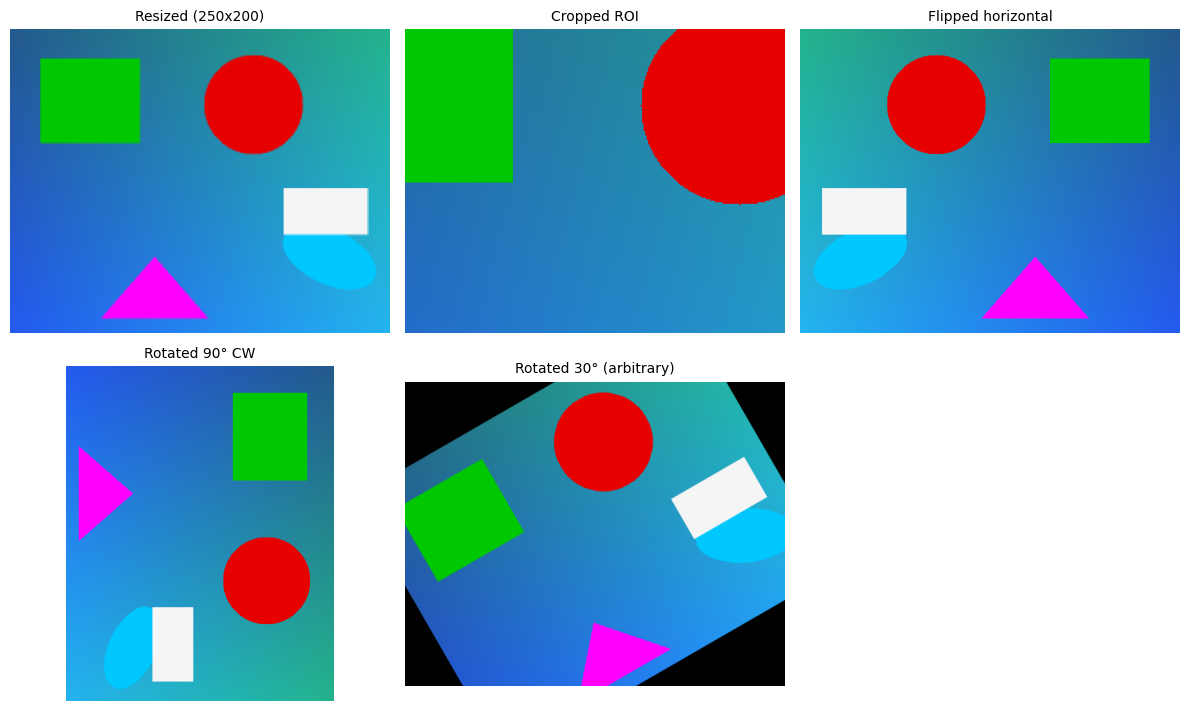

In [ ]:
resized_exact = cv2.resize(scene_img, (250, 200))
resized_scale = cv2.resize(scene_img, None, fx=0.6, fy=0.6, interpolation=cv2.INTER_AREA)
cropped = scene_img[50:250, 100:350]
flipped_h = cv2.flip(scene_img, 1)
rotated_90 = cv2.rotate(scene_img, cv2.ROTATE_90_CLOCKWISE)

h, w = scene_img.shape[:2]
M_rot = cv2.getRotationMatrix2D((w / 2, h / 2), 30, 1.0)   # center, angle (deg, CCW), scale
rotated_30 = cv2.warpAffine(scene_img, M_rot, (w, h))

show_grid(
    [resized_exact, cropped, flipped_h, rotated_90, rotated_30],
    ["Resized (250x200)", "Cropped ROI", "Flipped horizontal", "Rotated 90° CW", "Rotated 30° (arbitrary)"],
)

## 6. Color Spaces & Channel Operations

| Conversion | Function |
|---|---|
| BGR → Grayscale | `cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)` |
| BGR → RGB (for matplotlib/PIL) | `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` |
| BGR → HSV | `cv2.cvtColor(img, cv2.COLOR_BGR2HSV)` |
| BGR → LAB | `cv2.cvtColor(img, cv2.COLOR_BGR2LAB)` |
| BGR → YCrCb | `cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)` |
| Split channels | `b, g, r = cv2.split(img)` |
| Merge channels | `cv2.merge((b, g, r))` |

**Why so many color spaces?** HSV separates *color* (Hue) from *intensity* (Value), which makes color-based filtering far more robust to lighting than raw BGR — we use exactly that in Section 8. LAB and YCrCb separate luminance from color for similar reasons (compression, skin-tone detection, lighting-invariant processing).

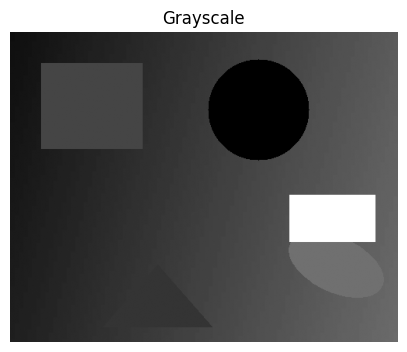

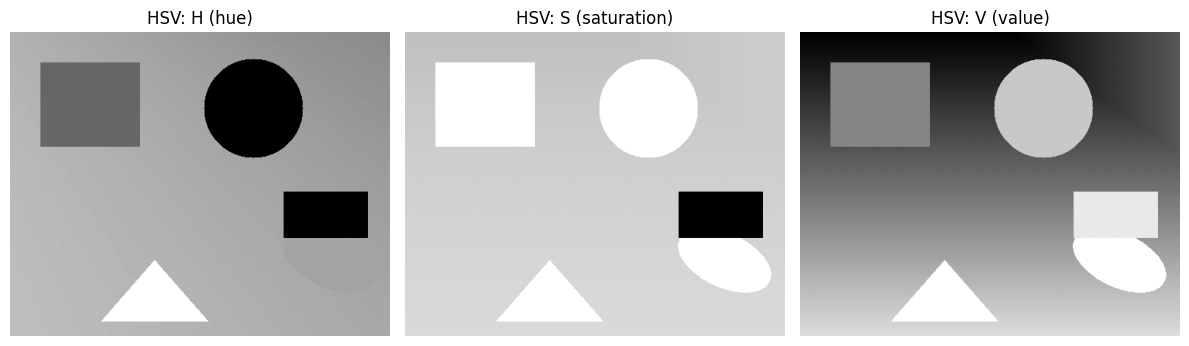

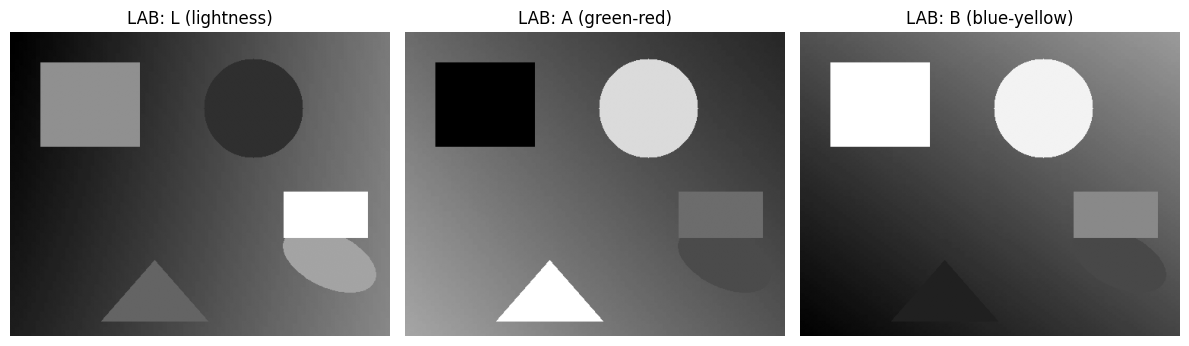

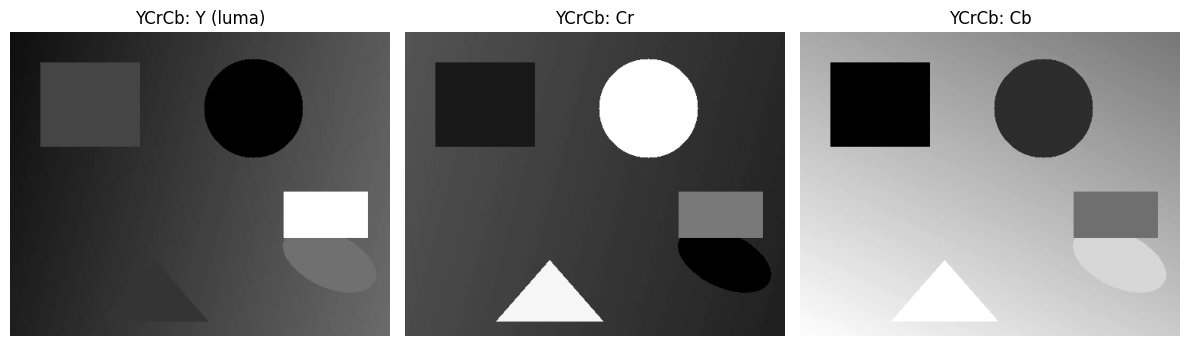

In [ ]:
gray = cv2.cvtColor(scene_img, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(scene_img, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(scene_img, cv2.COLOR_BGR2LAB)
ycrcb = cv2.cvtColor(scene_img, cv2.COLOR_BGR2YCrCb)

show(gray, "Grayscale")
show_channels(hsv, ["H (hue)", "S (saturation)", "V (value)"], "HSV")
show_channels(lab, ["L (lightness)", "A (green-red)", "B (blue-yellow)"], "LAB")
show_channels(ycrcb, ["Y (luma)", "Cr", "Cb"], "YCrCb")

Split/merge round-trip identical: True


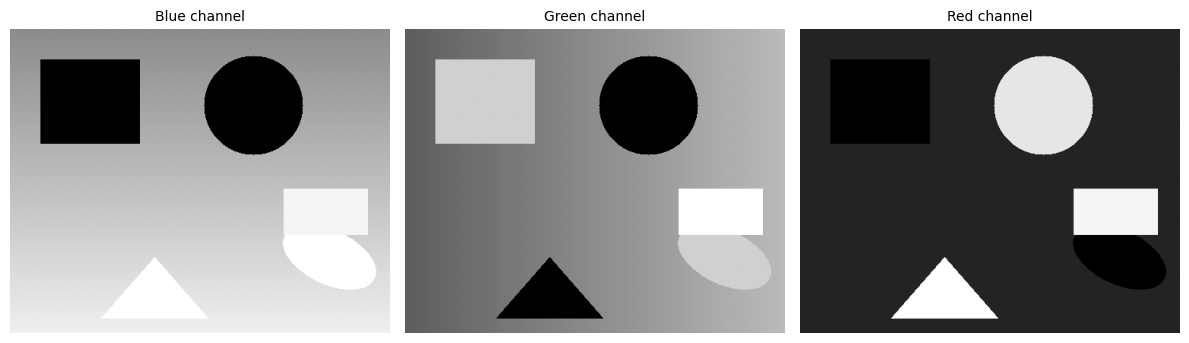

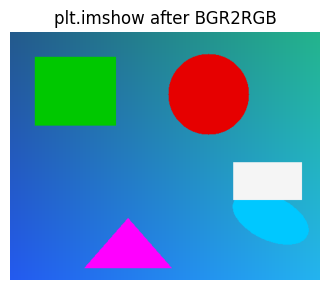

In [ ]:
b, g, r = cv2.split(scene_img)
merged = cv2.merge((b, g, r))                 # merge back -> identical to the original
print("Split/merge round-trip identical:", np.array_equal(scene_img, merged))
show_grid([b, g, r], ["Blue channel", "Green channel", "Red channel"])

# The BGR-vs-RGB gotcha in practice: convert before handing an image to matplotlib/PIL directly
rgb_for_matplotlib = cv2.cvtColor(scene_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(4, 4))
plt.imshow(rgb_for_matplotlib)   # correct colors because we converted first
plt.title("plt.imshow after BGR2RGB")
plt.axis("off")
plt.show()

## 7. Drawing Functions

| Shape | Function |
|---|---|
| Line | `cv2.line(img, pt1, pt2, color, thickness)` |
| Rectangle | `cv2.rectangle(img, pt1, pt2, color, thickness)` (`thickness=-1` fills it) |
| Circle | `cv2.circle(img, center, radius, color, thickness)` |
| Ellipse | `cv2.ellipse(img, center, axes, angle, startAngle, endAngle, color, thickness)` |
| Polygon outline | `cv2.polylines(img, [pts], isClosed, color, thickness)` |
| Filled polygon | `cv2.fillPoly(img, [pts], color)` |
| Text | `cv2.putText(img, text, org, fontFace, fontScale, color, thickness)` |

Pass `thickness=-1` to fill any shape. Pass `lineType=cv2.LINE_AA` for anti-aliased (smooth) edges — compare the plain line vs. the anti-aliased one below.

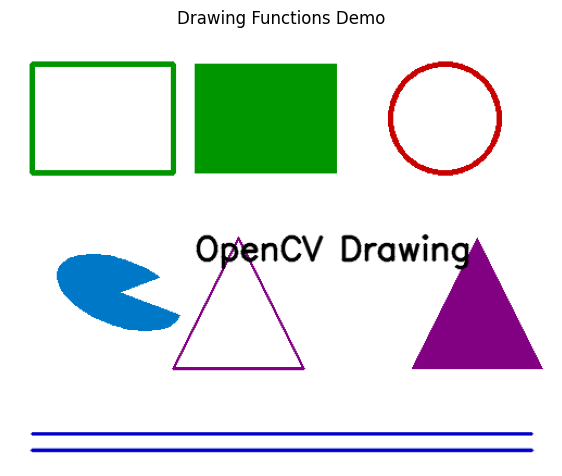

In [ ]:
canvas = np.full((400, 500, 3), 255, np.uint8)

cv2.line(canvas, (20, 370), (480, 370), (200, 0, 0), 2)                 # plain line
cv2.line(canvas, (20, 385), (480, 385), (200, 0, 0), 2, cv2.LINE_AA)     # anti-aliased line
cv2.rectangle(canvas, (20, 30), (150, 130), (0, 150, 0), 3)
cv2.rectangle(canvas, (170, 30), (300, 130), (0, 150, 0), -1)            # filled
cv2.circle(canvas, (400, 80), 50, (0, 0, 200), 3)
cv2.ellipse(canvas, (100, 240), (60, 30), 20, 0, 300, (200, 120, 0), -1)
tri_pts = np.array([[210, 190], [270, 310], [150, 310]], np.int32)
cv2.polylines(canvas, [tri_pts], True, (130, 0, 130), 2)
cv2.fillPoly(canvas, [tri_pts + [220, 0]], (130, 0, 130))
cv2.putText(canvas, "OpenCV Drawing", (170, 210), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 2, cv2.LINE_AA)

show(canvas, "Drawing Functions Demo", figsize=(7, 6))

## 8. Arithmetic & Bitwise Operations

| Task | Function |
|---|---|
| Add / subtract (saturating) | `cv2.add(img1, img2)` / `cv2.subtract(img1, img2)` |
| Weighted blend | `cv2.addWeighted(img1, α, img2, β, γ)` |
| Multiply / divide | `cv2.multiply(img1, img2)` / `cv2.divide(img1, img2)` |
| Bitwise AND / OR / XOR / NOT | `cv2.bitwise_and/or/xor/not(img1, img2, mask=...)` |

Images must be the **same size and type**. `cv2.add` *saturates* at 255 instead of wrapping around like plain NumPy `+` would — this matters a lot for image math.

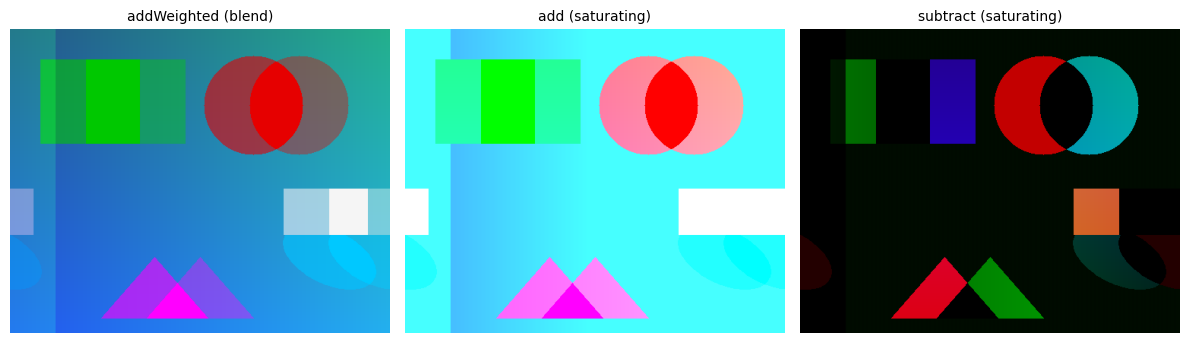

cv2.add(200,100)     = [255]  (correctly clipped to 255)
plain NumPy 200+100  = [44]  (wraps around to 44!)


In [ ]:
img2 = np.roll(scene_img, shift=60, axis=1)     # a cheap second same-size image: shift the first one

blended = cv2.addWeighted(scene_img, 0.6, img2, 0.4, 0)   # 0.6*img1 + 0.4*img2 + 0
added = cv2.add(scene_img, img2)                          # saturates at 255 (no wraparound)
subtracted = cv2.subtract(scene_img, img2)                 # saturates at 0

show_grid([blended, added, subtracted], ["addWeighted (blend)", "add (saturating)", "subtract (saturating)"])

# Saturating vs. wrap-around, made explicit:
a = np.uint8([[200]])   # a 1x1 "image" (must be 2-D, not a bare 1-D array, for cv2.add to treat it as pixels)
b = np.uint8([[100]])
print("cv2.add(200,100)     =", cv2.add(a, b).flatten(), " (correctly clipped to 255)")
print("plain NumPy 200+100  =", (a + b).flatten(), " (wraps around to 44!)")

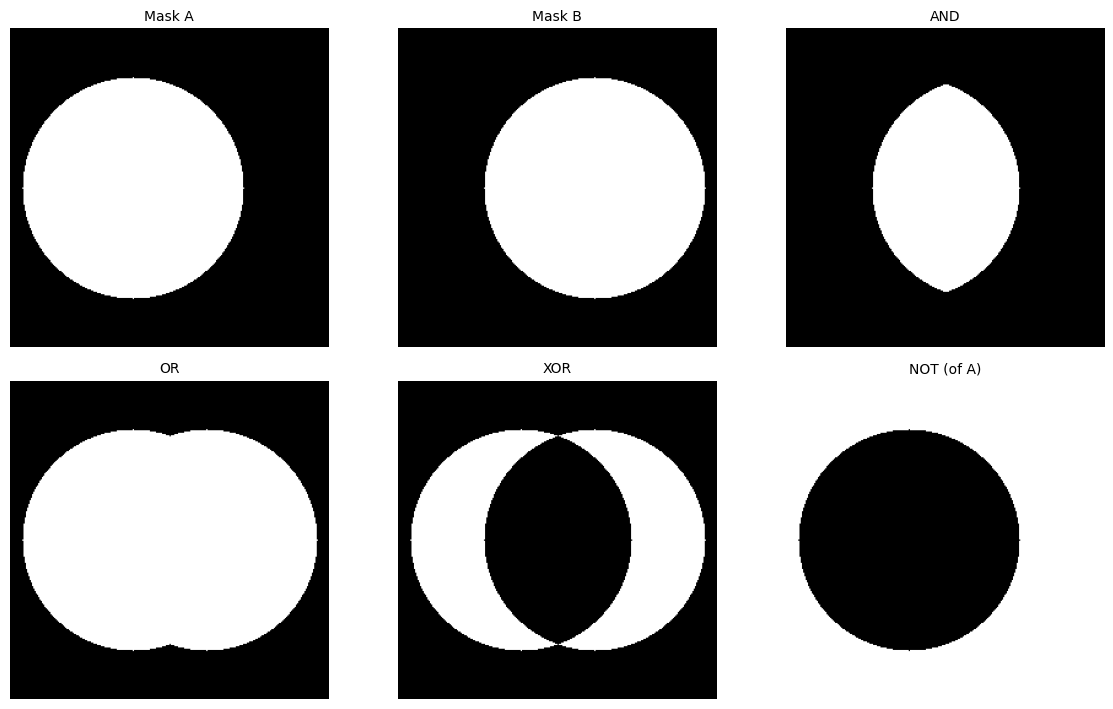

In [ ]:
# Classic AND/OR/XOR/NOT demo with two overlapping circular masks
mask_a = np.zeros((260, 260), np.uint8)
mask_b = np.zeros((260, 260), np.uint8)
cv2.circle(mask_a, (100, 130), 90, 255, -1)
cv2.circle(mask_b, (160, 130), 90, 255, -1)

bit_and = cv2.bitwise_and(mask_a, mask_b)
bit_or = cv2.bitwise_or(mask_a, mask_b)
bit_xor = cv2.bitwise_xor(mask_a, mask_b)
bit_not = cv2.bitwise_not(mask_a)

show_grid([mask_a, mask_b, bit_and, bit_or, bit_xor, bit_not],
          ["Mask A", "Mask B", "AND", "OR", "XOR", "NOT (of A)"], cols=3)

### Practical example: isolate an object by color (HSV masking)

This is the real-world use of bitwise operations: build a binary **mask** from a color range in HSV, then `bitwise_and` it with the original image to keep only matching pixels. Red wraps around hue 0°/180° in OpenCV's HSV, so it needs two ranges OR-ed together.

Pixels selected by the mask: 13273


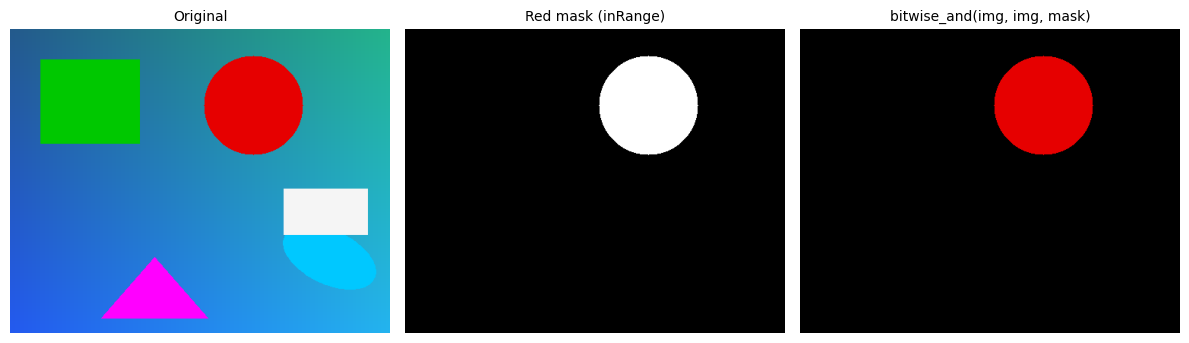

In [ ]:
hsv = cv2.cvtColor(scene_img, cv2.COLOR_BGR2HSV)

lower_red1, upper_red1 = np.array([0, 120, 70]), np.array([10, 255, 255])
lower_red2, upper_red2 = np.array([170, 120, 70]), np.array([180, 255, 255])
mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
red_mask = cv2.bitwise_or(mask1, mask2)

red_only = cv2.bitwise_and(scene_img, scene_img, mask=red_mask)

print("Pixels selected by the mask:", cv2.countNonZero(red_mask))
show_grid([scene_img, red_mask, red_only], ["Original", "Red mask (inRange)", "bitwise_and(img, img, mask)"])

## 9. Blurring & Smoothing (Filtering)

| Filter | Function | Best for |
|---|---|---|
| Average | `cv2.blur(img, (k,k))` | quick, cheap smoothing |
| Gaussian | `cv2.GaussianBlur(img, (k,k), sigma)` | general noise, pre-processing before edge detection |
| Median | `cv2.medianBlur(img, k)` | **salt-and-pepper** noise specifically |
| Bilateral | `cv2.bilateralFilter(img, d, sigmaColor, sigmaSpace)` | denoising **while keeping edges sharp** |
| Custom kernel | `cv2.filter2D(img, -1, kernel)` | sharpening, custom effects |

Different filters exist because different noise needs different tools — the two demos below show each filter matched against the noise type it's actually good at.

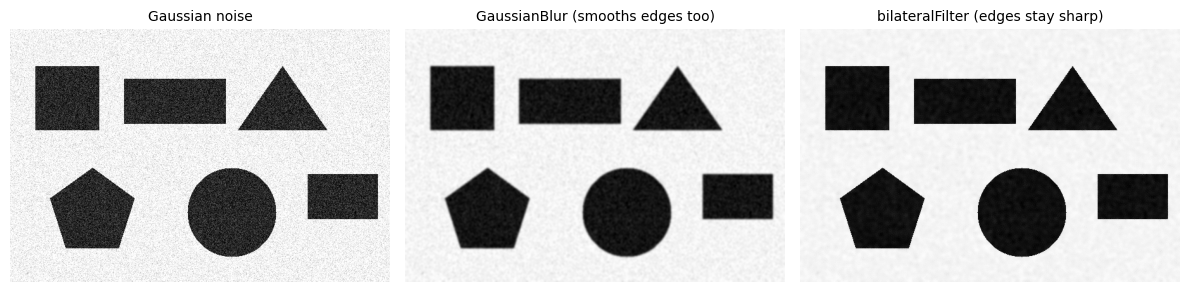

In [ ]:
gray_shapes = cv2.cvtColor(shapes_img, cv2.COLOR_BGR2GRAY)

# --- Gaussian noise -> Gaussian blur / bilateral filter ---
rng = np.random.RandomState(1)
gauss_noisy = np.clip(gray_shapes.astype(np.int16) + rng.normal(0, 25, gray_shapes.shape), 0, 255).astype(np.uint8)
g_blur = cv2.GaussianBlur(gauss_noisy, (7, 7), 0)
bilateral = cv2.bilateralFilter(gauss_noisy, 9, 75, 75)

show_grid([gauss_noisy, g_blur, bilateral],
          ["Gaussian noise", "GaussianBlur (smooths edges too)", "bilateralFilter (edges stay sharp)"])

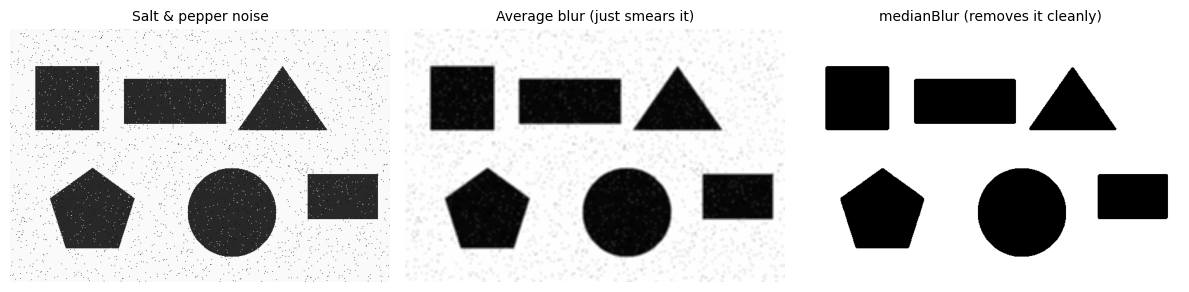

In [ ]:
# --- Salt-and-pepper noise -> median filter is the specialist tool here ---
rng = np.random.RandomState(2)
sp_noisy = gray_shapes.copy()
n = int(0.02 * sp_noisy.size)
ys, xs = rng.randint(0, sp_noisy.shape[0], n), rng.randint(0, sp_noisy.shape[1], n)
sp_noisy[ys[: n // 2], xs[: n // 2]] = 255
sp_noisy[ys[n // 2 :], xs[n // 2 :]] = 0

median = cv2.medianBlur(sp_noisy, 5)
avg = cv2.blur(sp_noisy, (5, 5))

show_grid([sp_noisy, avg, median],
          ["Salt & pepper noise", "Average blur (just smears it)", "medianBlur (removes it cleanly)"])

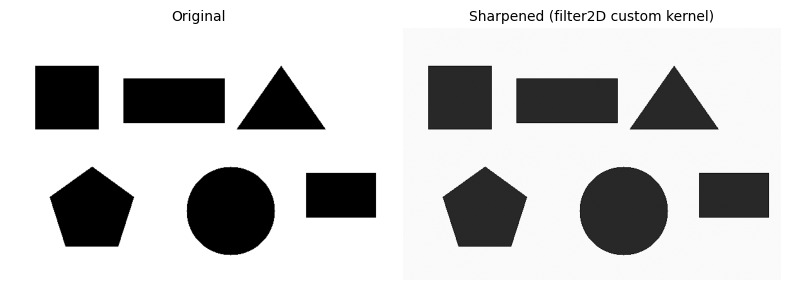

In [ ]:
# --- Custom kernel: sharpening with filter2D ---
kernel_sharpen = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened = cv2.filter2D(gray_shapes, -1, kernel_sharpen)
show_grid([gray_shapes, sharpened], ["Original", "Sharpened (filter2D custom kernel)"])

## 10. Thresholding

| Type | Function |
|---|---|
| Simple binary | `cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)` |
| Otsu's (auto threshold) | `cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)` |
| Adaptive | `cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, blockSize, C)` |

Other `THRESH_*` flags: `THRESH_BINARY_INV`, `THRESH_TRUNC`, `THRESH_TOZERO`, `THRESH_TOZERO_INV`.

Global thresholds (simple or Otsu) pick **one** cutoff for the whole image — great when lighting is even. Adaptive thresholding computes a *local* threshold per neighborhood, so it survives uneven lighting that would break a global threshold. The demo below proves it: the same 6 shapes, lit unevenly, cost the global threshold one missed shape.

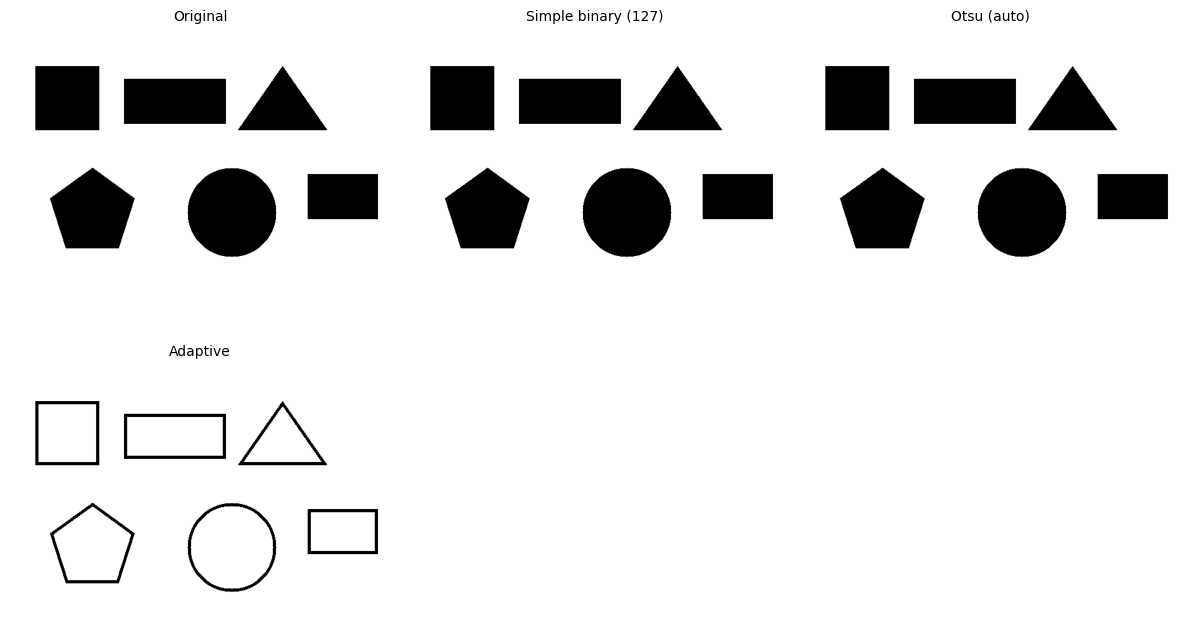

In [ ]:
_, th_binary = cv2.threshold(gray_shapes, 127, 255, cv2.THRESH_BINARY)
_, th_otsu = cv2.threshold(gray_shapes, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
th_adaptive = cv2.adaptiveThreshold(gray_shapes, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

show_grid([gray_shapes, th_binary, th_otsu, th_adaptive],
          ["Original", "Simple binary (127)", "Otsu (auto)", "Adaptive"])

6 shapes drawn. Global threshold recovers 5. Adaptive threshold recovers 6.


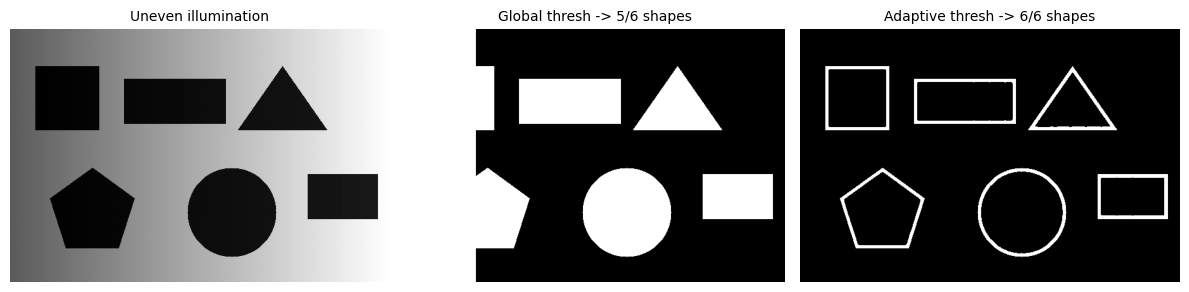

In [ ]:
# Uneven lighting: global threshold vs. adaptive threshold, with a real pixel-count outcome
yy, xx = np.mgrid[0:gray_shapes.shape[0], 0:gray_shapes.shape[1]]
illumination = 0.4 + 0.6 * xx / gray_shapes.shape[1]                     # dim on the left, bright on the right
uneven = np.clip(gray_shapes.astype(np.float32) * illumination, 0, 255).astype(np.uint8)

_, th_global_uneven = cv2.threshold(uneven, 127, 255, cv2.THRESH_BINARY_INV)
th_adaptive_uneven = cv2.adaptiveThreshold(uneven, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 15, 3)

cnts_g, _ = cv2.findContours(th_global_uneven, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts_a, _ = cv2.findContours(th_adaptive_uneven, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts_g = [c for c in cnts_g if cv2.contourArea(c) > 200]
cnts_a = [c for c in cnts_a if cv2.contourArea(c) > 200]

print(f"6 shapes drawn. Global threshold recovers {len(cnts_g)}. Adaptive threshold recovers {len(cnts_a)}.")
show_grid([uneven, th_global_uneven, th_adaptive_uneven],
          ["Uneven illumination", f"Global thresh -> {len(cnts_g)}/6 shapes", f"Adaptive thresh -> {len(cnts_a)}/6 shapes"])

## 11. Morphological Operations

Morphological ops work on binary (thresholded) images using a small **structuring element** (kernel) that slides across the image.

| Operation | Function | Effect |
|---|---|---|
| Erode | `cv2.erode(img, kernel)` | shrinks white regions, removes small specks |
| Dilate | `cv2.dilate(img, kernel)` | grows white regions, fills small holes |
| Open (erode→dilate) | `cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)` | removes small noise blobs |
| Close (dilate→erode) | `cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)` | fills small holes/gaps |
| Gradient | `cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)` | outlines (dilate − erode) |
| Structuring elements | `cv2.getStructuringElement(cv2.MORPH_RECT / _ELLIPSE / _CROSS, (k,k))` |

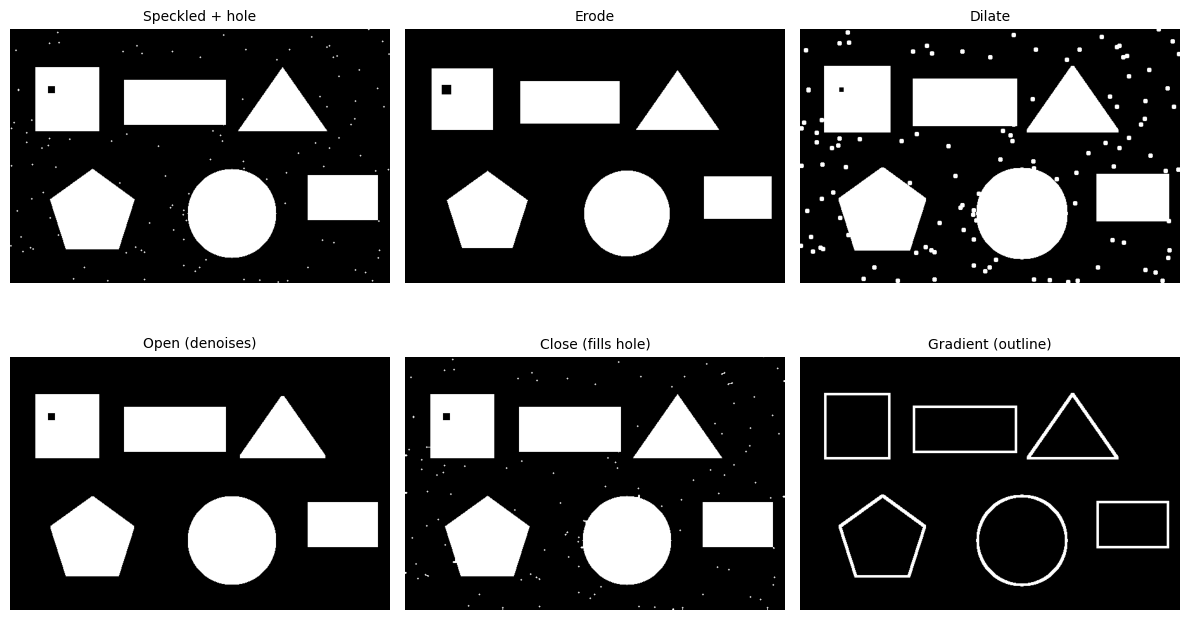

In [ ]:
_, binary_shapes = cv2.threshold(gray_shapes, 200, 255, cv2.THRESH_BINARY_INV)

# Add a bit of speckle noise + a small hole so open/close have something real to fix
speckled = binary_shapes.copy()
rng = np.random.RandomState(3)
speck_pts = rng.randint(0, [speckled.shape[1], speckled.shape[0]], size=(150, 2))
for x, y in speck_pts:
    cv2.circle(speckled, (x, y), 1, 255, -1)
cv2.rectangle(speckled, (60, 90), (70, 100), 0, -1)   # punch a small hole in the square

kernel = np.ones((5, 5), np.uint8)
eroded = cv2.erode(speckled, kernel)
dilated = cv2.dilate(speckled, kernel)
opened = cv2.morphologyEx(speckled, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(speckled, cv2.MORPH_CLOSE, kernel)
gradient = cv2.morphologyEx(binary_shapes, cv2.MORPH_GRADIENT, kernel)

show_grid([speckled, eroded, dilated, opened, closed, gradient],
          ["Speckled + hole", "Erode", "Dilate", "Open (denoises)", "Close (fills hole)", "Gradient (outline)"], cols=3)

## 12. Edge Detection

| Method | Function | Notes |
|---|---|---|
| Sobel | `cv2.Sobel(img, cv2.CV_64F, dx, dy, ksize)` | directional gradient (x or y) |
| Laplacian | `cv2.Laplacian(img, cv2.CV_64F)` | second derivative, all directions at once |
| Canny | `cv2.Canny(img, threshold1, threshold2)` | the industry-standard multi-stage detector |

**Canny's two thresholds:** `threshold1` is the lower bound for "weak" edges, `threshold2` the upper bound for "strong" edges — Canny keeps strong edges, discards anything below the lower bound, and keeps weak edges *only if connected to a strong one* (this is called hysteresis). We use `cv2.CV_64F` for Sobel/Laplacian so gradients can go negative before we take their absolute value.

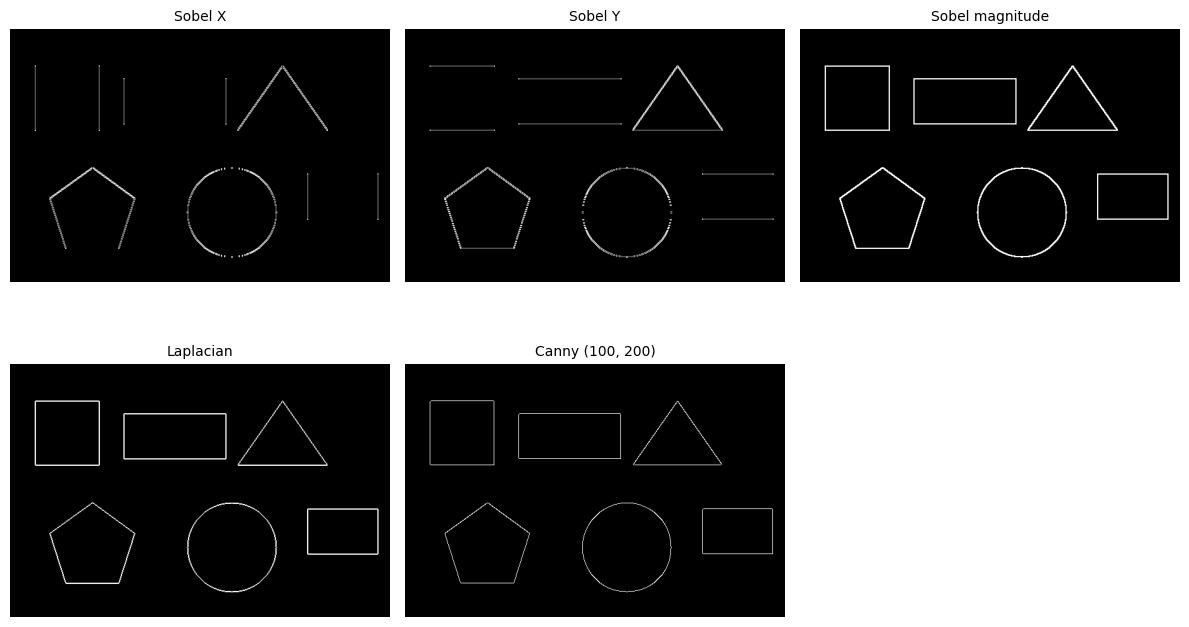

In [ ]:
sobel_x = cv2.Sobel(gray_shapes, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray_shapes, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobel_x, sobel_y)
laplacian = cv2.Laplacian(gray_shapes, cv2.CV_64F)
canny_edges = cv2.Canny(gray_shapes, 100, 200)

show_grid(
    [np.uint8(np.abs(sobel_x)), np.uint8(np.abs(sobel_y)), np.uint8(np.clip(sobel_combined, 0, 255)),
     np.uint8(np.abs(laplacian)), canny_edges],
    ["Sobel X", "Sobel Y", "Sobel magnitude", "Laplacian", "Canny (100, 200)"], cols=3,
)

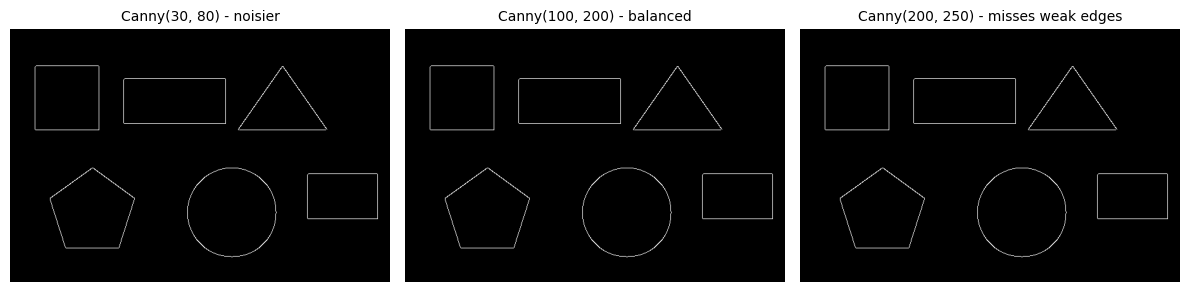

In [ ]:
# Canny threshold sensitivity - a classic tuning question
fig_imgs = [cv2.Canny(gray_shapes, lo, hi) for lo, hi in [(30, 80), (100, 200), (200, 250)]]
show_grid(fig_imgs, ["Canny(30, 80) - noisier", "Canny(100, 200) - balanced", "Canny(200, 250) - misses weak edges"])

## 13. Contours & Shape Classification

| Task | Function |
|---|---|
| Find contours | `contours, hierarchy = cv2.findContours(binary, mode, method)` |
| Draw contours | `cv2.drawContours(img, contours, -1, color, thickness)` |
| Area / perimeter | `cv2.contourArea(cnt)` / `cv2.arcLength(cnt, True)` |
| Bounding box | `cv2.boundingRect(cnt)` |
| Simplify to N points | `cv2.approxPolyDP(cnt, epsilon, True)` |
| Centroid | via `cv2.moments(cnt)` → `cx = M['m10']/M['m00']` |

Retrieval modes: `RETR_EXTERNAL` (outer contours only), `RETR_LIST`, `RETR_TREE` (full hierarchy). Approximation methods: `CHAIN_APPROX_NONE` (every point), `CHAIN_APPROX_SIMPLE` (compresses straight segments).

**Beyond the cheat sheet:** counting a contour's vertices after `approxPolyDP` is a simple, effective way to classify shapes — 3 vertices is a triangle, 4 is a square/rectangle (check the aspect ratio to tell them apart), 5 is a pentagon, and anything else is checked for circularity.

Found 6 contours


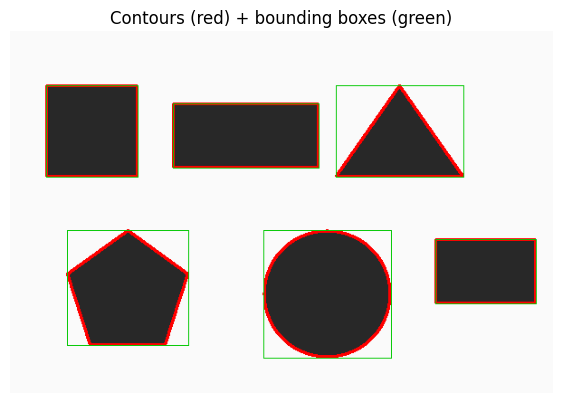

In [ ]:
_, thresh = cv2.threshold(gray_shapes, 200, 255, cv2.THRESH_BINARY_INV)
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"Found {len(contours)} contours")

annotated = shapes_img.copy()
cv2.drawContours(annotated, contours, -1, (0, 0, 255), 2)
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(annotated, (x, y), (x + w, y + h), (0, 200, 0), 1)

show(annotated, "Contours (red) + bounding boxes (green)", figsize=(7, 5))

Rectangle  | area=   7700 | bbox=(470,230,111,71)
Circle     | area=  15176 | bbox=(280,220,141,141)
Pentagon   | area=  11616 | bbox=(63,220,134,127)
Rectangle  | area=  11200 | bbox=(180,80,161,71)
Triangle   | area=   7000 | bbox=(360,60,141,101)
Square     | area=  10000 | bbox=(40,60,101,101)


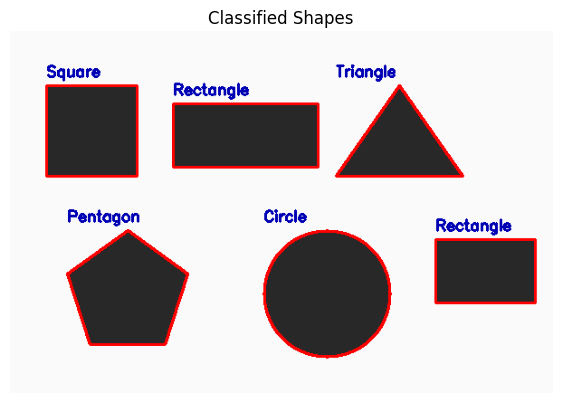

In [ ]:
def classify_shape(cnt):
    """Classify a contour as Triangle / Square / Rectangle / Pentagon / Circle by vertex count."""
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
    vertices = len(approx)
    area = cv2.contourArea(cnt)
    if vertices == 3:
        return "Triangle"
    elif vertices == 4:
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = w / float(h)
        return "Square" if 0.9 <= aspect_ratio <= 1.1 else "Rectangle"
    elif vertices == 5:
        return "Pentagon"
    else:
        circularity = 4 * np.pi * area / (peri ** 2)   # 1.0 for a perfect circle
        return "Circle" if circularity > 0.8 else f"Polygon ({vertices} sides)"


labeled = shapes_img.copy()
for cnt in contours:
    name = classify_shape(cnt)
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.drawContours(labeled, [cnt], -1, (0, 0, 255), 2)
    cv2.putText(labeled, name, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (180, 0, 0), 2)
    print(f"{name:10s} | area={cv2.contourArea(cnt):7.0f} | bbox=({x},{y},{w},{h})")

show(labeled, "Classified Shapes", figsize=(7, 5))

## 14. Histograms & Equalization

| Task | Function |
|---|---|
| Compute histogram | `cv2.calcHist([img], [channel], mask, [256], [0, 256])` |
| Global equalization | `cv2.equalizeHist(gray)` |
| Adaptive equalization | `cv2.createCLAHE(clipLimit, tileGridSize).apply(gray)` |

Plain `equalizeHist` stretches contrast over the **whole** image; **CLAHE** (Contrast Limited Adaptive Histogram Equalization) does it in small tiles, which improves local contrast without blowing out already-well-lit regions.

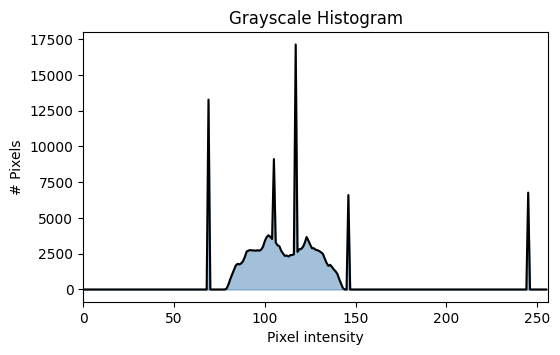

In [ ]:
gray_scene = cv2.cvtColor(scene_img, cv2.COLOR_BGR2GRAY)
hist = cv2.calcHist([gray_scene], [0], None, [256], [0, 256])

plt.figure(figsize=(6, 3.5))
plt.plot(hist, color="black")
plt.fill_between(range(256), hist.flatten(), color="steelblue", alpha=0.5)
plt.title("Grayscale Histogram")
plt.xlabel("Pixel intensity")
plt.ylabel("# Pixels")
plt.xlim([0, 256])
plt.show()

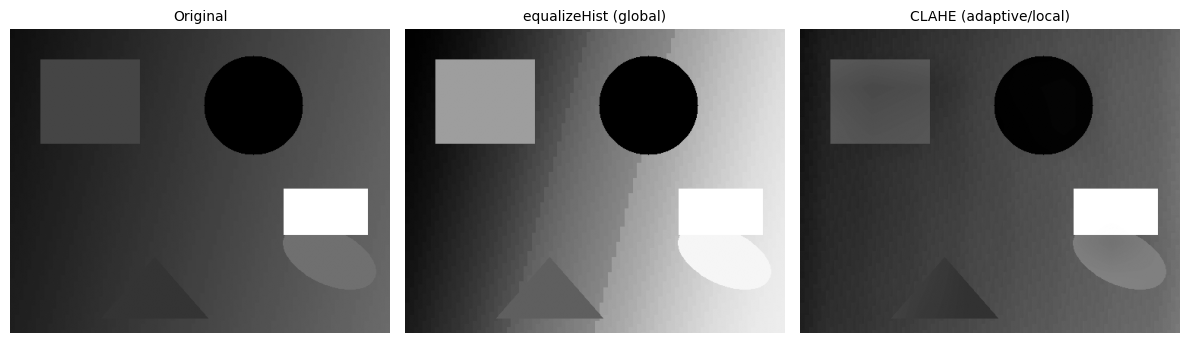

In [ ]:
equalized = cv2.equalizeHist(gray_scene)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_img = clahe.apply(gray_scene)

show_grid([gray_scene, equalized, clahe_img], ["Original", "equalizeHist (global)", "CLAHE (adaptive/local)"])

## 15. Geometric Transformations (Affine & Perspective)

| Transform | Matrix builder | Apply with |
|---|---|---|
| Translation | build `[[1,0,tx],[0,1,ty]]` by hand | `cv2.warpAffine` |
| Rotation/scale | `cv2.getRotationMatrix2D(center, angle, scale)` | `cv2.warpAffine` |
| Affine (from 3 point pairs) | `cv2.getAffineTransform(src3pts, dst3pts)` | `cv2.warpAffine` |
| Perspective (from 4 point pairs) | `cv2.getPerspectiveTransform(src4pts, dst4pts)` | `cv2.warpPerspective` |

**Affine** transforms preserve parallel lines (translation, rotation, scale, shear). **Perspective** transforms don't — they can simulate a change of viewpoint (e.g. "unwarping" a photographed document), which is why they need 4 point correspondences instead of 3.

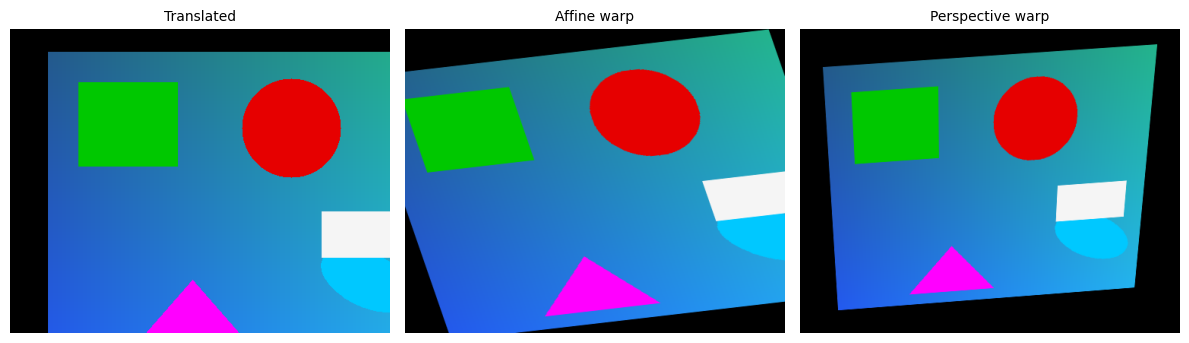

In [ ]:
h, w = scene_img.shape[:2]

# Translation
M_translate = np.float32([[1, 0, 50], [0, 1, 30]])
translated = cv2.warpAffine(scene_img, M_translate, (w, h))

# General affine from 3 point correspondences
pts1 = np.float32([[50, 50], [w - 50, 50], [50, h - 50]])
pts2 = np.float32([[10, 100], [w - 60, 50], [100, h - 40]])
M_affine = cv2.getAffineTransform(pts1, pts2)
affine_warped = cv2.warpAffine(scene_img, M_affine, (w, h))

# Perspective from 4 point correspondences
pts1p = np.float32([[0, 0], [w, 0], [0, h], [w, h]])
pts2p = np.float32([[30, 50], [w - 30, 20], [50, h - 30], [w - 60, h - 60]])
M_persp = cv2.getPerspectiveTransform(pts1p, pts2p)
persp_warped = cv2.warpPerspective(scene_img, M_persp, (w, h))

show_grid([translated, affine_warped, persp_warped], ["Translated", "Affine warp", "Perspective warp"])

## 16. Feature Detection (ORB, SIFT, AKAZE, BRISK)

A **keypoint** is a distinctive, repeatable location (a corner, blob, or textured patch); a **descriptor** is a numeric fingerprint of the patch around it, used to recognize that same point in another image.

| Detector | Create | Descriptor type | Notes |
|---|---|---|---|
| ORB | `cv2.ORB_create(nfeatures=500)` | binary | fast, free, good default |
| SIFT | `cv2.SIFT_create()` | float | very robust, patent-free since OpenCV 4.4+ |
| AKAZE | `cv2.AKAZE_create()` | binary | good on nonlinear/blurred content |
| BRISK | `cv2.BRISK_create()` | binary | fast alternative to ORB |

All four share the same `detectAndCompute(gray_img, mask)` interface, so swapping one for another is a one-line change.

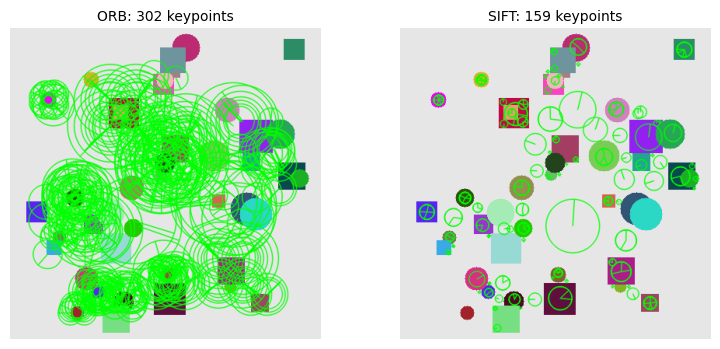

In [ ]:
gray_tex = cv2.cvtColor(textured_img, cv2.COLOR_BGR2GRAY)

orb = cv2.ORB_create(nfeatures=300)
keypoints_orb, _ = orb.detectAndCompute(gray_tex, None)
orb_vis = cv2.drawKeypoints(textured_img, keypoints_orb, None, color=(0, 255, 0),
                             flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

sift = cv2.SIFT_create()
keypoints_sift, _ = sift.detectAndCompute(gray_tex, None)
sift_vis = cv2.drawKeypoints(textured_img, keypoints_sift, None, color=(0, 255, 0),
                              flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

show_grid([orb_vis, sift_vis], [f"ORB: {len(keypoints_orb)} keypoints", f"SIFT: {len(keypoints_sift)} keypoints"])

In [ ]:
# Quick comparison across all four detectors
detectors = {
    "ORB": cv2.ORB_create(nfeatures=500),
    "SIFT": cv2.SIFT_create(),
    "AKAZE": cv2.AKAZE_create(),
    "BRISK": cv2.BRISK_create(),
}
print(f"{'Detector':10s} {'Keypoints':10s} {'Descriptor length':18s}")
for name, det in detectors.items():
    kp, desc = det.detectAndCompute(gray_tex, None)
    dsize = desc.shape[1] if desc is not None else 0
    print(f"{name:10s} {len(kp):<10d} {dsize:<18d}")

Detector   Keypoints  Descriptor length 
ORB        501        32                
SIFT       159        128               
AKAZE      325        61                
BRISK      876        64                


## 17. Feature Matching (BF, KNN, Ratio Test)

| Task | Function |
|---|---|
| Brute-force match (binary descriptors) | `cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)` then `.match(des1, des2)` |
| K-nearest-neighbor match (float descriptors) | `cv2.BFMatcher()` then `.knnMatch(des1, des2, k=2)` |
| Lowe's ratio test | keep a match only if `m.distance < 0.75 * n.distance` |
| Draw matches | `cv2.drawMatches(img1, kp1, img2, kp2, matches, None)` |

`textured_warped_img` is `textured_img` rotated 25° and scaled to 90% — matching finds correspondences **despite** that transform, which is exactly what template matching (Section 18) cannot do.

ORB: 405 vs 400 keypoints -> 174 matches (showing best 40)


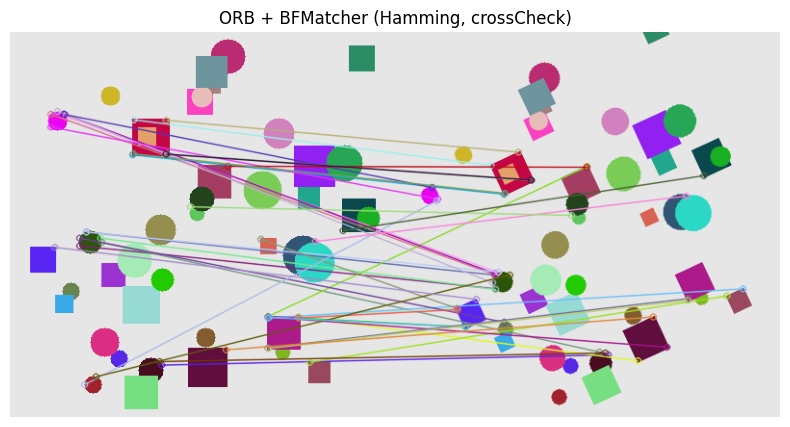

In [ ]:
gray1 = cv2.cvtColor(textured_img, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(textured_warped_img, cv2.COLOR_BGR2GRAY)

# --- ORB + brute-force Hamming matching (binary descriptors) ---
orb = cv2.ORB_create(nfeatures=400)
kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda m: m.distance)

orb_match_vis = cv2.drawMatches(textured_img, kp1, textured_warped_img, kp2, matches[:40], None,
                                 flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
print(f"ORB: {len(kp1)} vs {len(kp2)} keypoints -> {len(matches)} matches (showing best 40)")
show(orb_match_vis, "ORB + BFMatcher (Hamming, crossCheck)", figsize=(10, 5))

SIFT: 159 candidate pairs -> 84 pass the ratio test


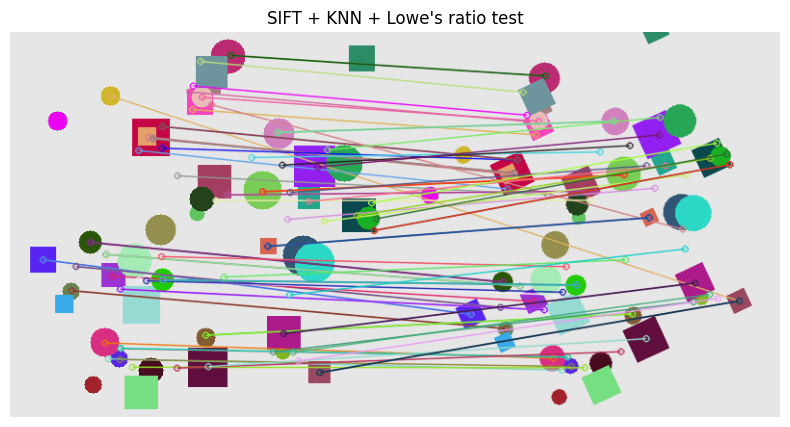

In [ ]:
# --- SIFT + KNN matching + Lowe's ratio test (float descriptors) ---
sift = cv2.SIFT_create()
kp1s, des1s = sift.detectAndCompute(gray1, None)
kp2s, des2s = sift.detectAndCompute(gray2, None)

bf2 = cv2.BFMatcher()
knn_matches = bf2.knnMatch(des1s, des2s, k=2)
good_matches = [m for m, n in knn_matches if m.distance < 0.75 * n.distance]

sift_match_vis = cv2.drawMatches(textured_img, kp1s, textured_warped_img, kp2s, good_matches, None,
                                  flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
print(f"SIFT: {len(knn_matches)} candidate pairs -> {len(good_matches)} pass the ratio test")
show(sift_match_vis, "SIFT + KNN + Lowe's ratio test", figsize=(10, 5))

## 18. Template Matching

| Task | Function |
|---|---|
| Slide a template over an image | `res = cv2.matchTemplate(img, template, cv2.TM_CCOEFF_NORMED)` |
| Find the best match location | `_, max_val, _, max_loc = cv2.minMaxLoc(res)` |

Template matching is simple and exact, but it is **not** rotation- or scale-invariant — a template only finds copies of itself at (roughly) the same size and orientation. That's precisely the gap feature matching (Section 17) fills.

Best match score: 1.0000 at (355, 205)


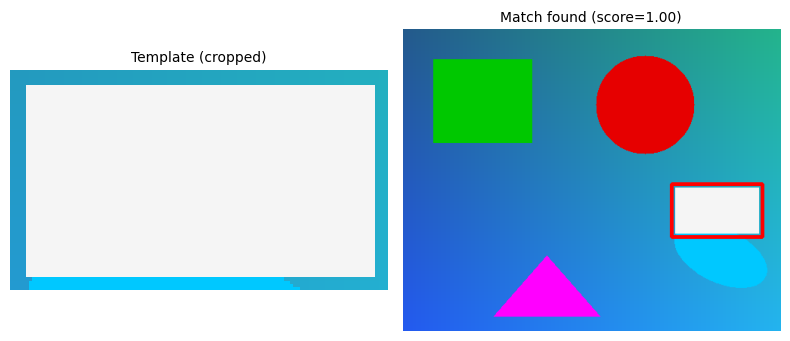

In [ ]:
template = scene_img[205:275, 355:475].copy()   # crop the near-white rectangle out of scene_img
th, tw = template.shape[:2]

result = cv2.matchTemplate(scene_img, template, cv2.TM_CCOEFF_NORMED)
_, max_val, _, max_loc = cv2.minMaxLoc(result)

match_vis = scene_img.copy()
cv2.rectangle(match_vis, max_loc, (max_loc[0] + tw, max_loc[1] + th), (0, 0, 255), 3)

print(f"Best match score: {max_val:.4f} at {max_loc}")
show_grid([template, match_vis], ["Template (cropped)", f"Match found (score={max_val:.2f})"])

## 19. Hough Transforms (Lines & Circles)

| Task | Function |
|---|---|
| Detect lines (classic) | `cv2.HoughLines(edges, rho, theta, threshold)` |
| Detect line **segments** | `cv2.HoughLinesP(edges, rho, theta, threshold, minLineLength, maxLineGap)` |
| Detect circles | `cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, dp, minDist, param1, param2, minRadius, maxRadius)` |

`HoughLinesP` runs on **edges** (typically Canny output); `HoughCircles` runs on a (lightly blurred) **grayscale** image directly — it computes its own internal edge/gradient map.

HoughLinesP found 9 segments for the 3 drawn lines.
Note: a single thick stroke has two edges (one on each side), and segments often split
further near corners/intersections — merging nearby collinear segments is a common next step.


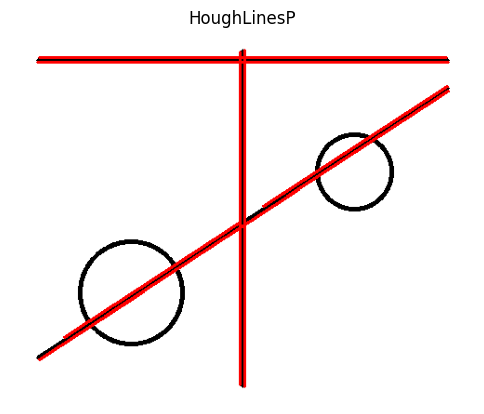

In [ ]:
edges = cv2.Canny(lines_circles_img, 50, 150)
detected_lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=80, minLineLength=50, maxLineGap=10)

line_vis = cv2.cvtColor(lines_circles_img, cv2.COLOR_GRAY2BGR)
for l in detected_lines:
    x1, y1, x2, y2 = l[0]
    cv2.line(line_vis, (x1, y1), (x2, y2), (0, 0, 255), 2)

print(f"HoughLinesP found {len(detected_lines)} segments for the 3 drawn lines.")
print("Note: a single thick stroke has two edges (one on each side), and segments often split")
print("further near corners/intersections — merging nearby collinear segments is a common next step.")
show(line_vis, "HoughLinesP", figsize=(6, 5))

HoughCircles found 2 circles (2 were drawn).


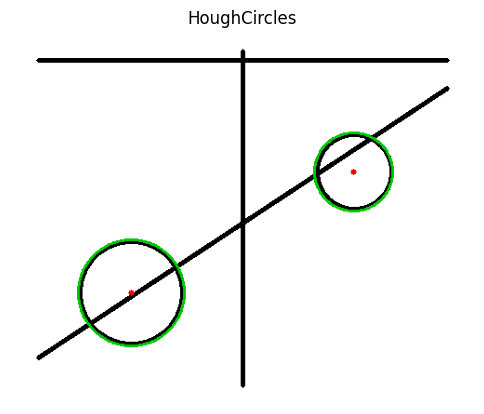

In [ ]:
blurred_lc = cv2.GaussianBlur(lines_circles_img, (9, 9), 2)
detected_circles = cv2.HoughCircles(blurred_lc, cv2.HOUGH_GRADIENT, dp=1, minDist=50,
                                     param1=50, param2=30, minRadius=20, maxRadius=100)

circle_vis = cv2.cvtColor(lines_circles_img, cv2.COLOR_GRAY2BGR)
if detected_circles is not None:
    for x, y, r in detected_circles[0]:
        cv2.circle(circle_vis, (int(x), int(y)), int(r), (0, 200, 0), 2)
        cv2.circle(circle_vis, (int(x), int(y)), 3, (0, 0, 255), -1)

print(f"HoughCircles found {0 if detected_circles is None else len(detected_circles[0])} circles (2 were drawn).")
show(circle_vis, "HoughCircles", figsize=(6, 5))

## 20. Object Detection with Haar Cascades

| Task | Function |
|---|---|
| Load a pretrained cascade | `cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')` |
| Detect | `cascade.detectMultiScale(gray, scaleFactor, minNeighbors)` |

`opencv-python` ships a folder of pretrained Haar cascade XML files, exposed at `cv2.data.haarcascades`. There's a face detector, eye detector, smile detector, and several others.

**Honest note on the demo below:** Haar cascades are trained on the statistics of *real photographs* — gradients, shading, texture. We don't use real photos anywhere in this notebook, so rather than fake a result, we run the exact same detector on a simple synthetic "face" doodle and report whatever it actually finds. Point this same code at one of your own photos and it works well; a hand-drawn circle-with-two-dots usually won't fool it, which is itself a useful thing to know about how these detectors work.

Cascade loaded OK: True
Faces detected on the synthetic doodle: 0


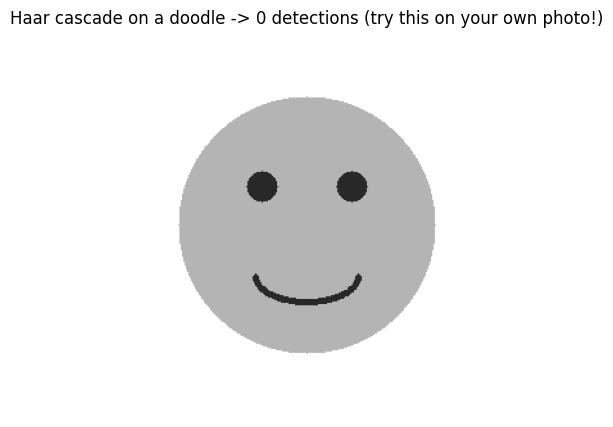

In [ ]:
def make_face_doodle(w=300, h=300):
    img = np.full((h, w), 255, np.uint8)
    cv2.circle(img, (150, 150), 100, 180, -1)                          # face
    cv2.circle(img, (115, 120), 12, 40, -1)                             # left eye
    cv2.circle(img, (185, 120), 12, 40, -1)                             # right eye
    cv2.ellipse(img, (150, 190), (40, 20), 0, 0, 180, 40, 3)            # smile
    return img

face_doodle = make_face_doodle()
cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(cascade_path)
print("Cascade loaded OK:", not face_cascade.empty())

faces = face_cascade.detectMultiScale(face_doodle, scaleFactor=1.1, minNeighbors=5)
print(f"Faces detected on the synthetic doodle: {len(faces)}")

result = cv2.cvtColor(face_doodle, cv2.COLOR_GRAY2BGR)
for (x, y, w, h) in faces:
    cv2.rectangle(result, (x, y), (x + w, y + h), (0, 255, 0), 2)

show(result, f"Haar cascade on a doodle -> {len(faces)} detections (try this on your own photo!)")

# For a real photo:
# img = cv2.imread('your_photo.jpg')
# gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# faces = face_cascade.detectMultiScale(gray, 1.1, 5)

## 21. Video I/O (Writing & Reading Video)

| Task | Function |
|---|---|
| Open a video file / webcam | `cv2.VideoCapture('file.mp4')` or `cv2.VideoCapture(0)` for webcam index 0 |
| Read frame-by-frame | `ret, frame = cap.read()` — loop until `ret` is `False` |
| Release | `cap.release()` |
| Write video | `cv2.VideoWriter(path, fourcc, fps, (w, h))`, then `.write(frame)` per frame, then `.release()` |
| Fourcc codes | `cv2.VideoWriter_fourcc(*'mp4v')`, `*'XVID'`, `*'MJPG'` |

There's no webcam in this sandboxed notebook, so instead of just showing the code, we **actually write a short synthetic video to disk and read it back** — the full round trip, genuinely executed.

In [ ]:
def create_demo_video(path="/tmp/demo_video.mp4", w=320, h=240, n_frames=40, fps=20):
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(path, fourcc, fps, (w, h))
    for i in range(n_frames):
        frame = np.full((h, w, 3), (40, 40, 40), np.uint8)
        x = int(20 + (w - 40) * i / (n_frames - 1))
        cv2.circle(frame, (x, h // 2), 22, (0, 165, 255), -1)
        cv2.putText(frame, f"Frame {i+1}/{n_frames}", (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        writer.write(frame)
    writer.release()
    return path

video_path = create_demo_video()
print("Video written to:", video_path)

Video written to: /tmp/demo_video.mp4


Reported by VideoCapture -> frames: 40, fps: 20.0
Actually read back 40 frames


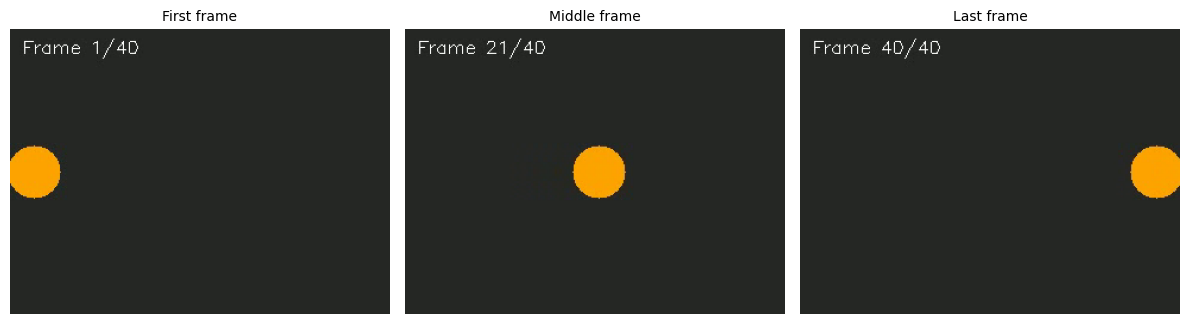

In [ ]:
cap = cv2.VideoCapture(video_path)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
print(f"Reported by VideoCapture -> frames: {frame_count}, fps: {fps}")

frames = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(frame)
cap.release()

print(f"Actually read back {len(frames)} frames")
show_grid([frames[0], frames[len(frames) // 2], frames[-1]], ["First frame", "Middle frame", "Last frame"])

# --- Script-only real-time loop pattern (webcam) ---
# cap = cv2.VideoCapture(0)
# while True:
#     ret, frame = cap.read()
#     if not ret: break
#     cv2.imshow('Video', frame)
#     if cv2.waitKey(1) == 27:   # ESC to quit
#         break
# cap.release(); cv2.destroyAllWindows()

## 22. Camera Calibration Basics

| Task | Function |
|---|---|
| Find chessboard corners | `cv2.findChessboardCorners(gray, patternSize)` |
| Refine corner locations | `cv2.cornerSubPix(gray, corners, winSize, zeroZone, criteria)` |
| Draw them | `cv2.drawChessboardCorners(img, patternSize, corners, found)` |
| Calibrate | `cv2.calibrateCamera(objpoints, imgpoints, imageSize, None, None)` |
| Undistort | `cv2.undistort(img, K, dist)` |

`patternSize` is the number of **inner corners** (intersections), not squares: a 9×6-square board has an 8×5 corner grid.

Corner detection works on a single image and we run it for real below. Full calibration is different — it needs **10-20 photos of one physical checkerboard from different real angles** so the solver can separate lens distortion from viewpoint. Faking that with 2D-only warps of a flat image would just produce numbers that look like a calibration without meaning anything, so instead we give you a correct, ready-to-use function: define it, don't fake-run it, and point it at your own photos.

Chessboard corners found: True | count: 40


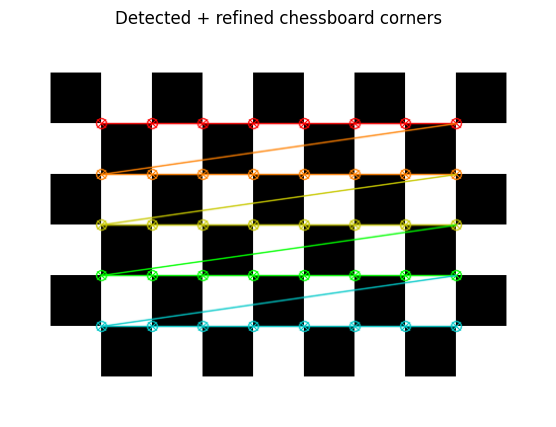

In [ ]:
pattern_size = (8, 5)   # inner corners for our 9x6-square board
gray_board = checkerboard_img.copy()

found, corners = cv2.findChessboardCorners(gray_board, pattern_size)
print("Chessboard corners found:", found, "| count:", len(corners) if found else 0)

if found:
    corners_refined = cv2.cornerSubPix(
        gray_board, corners, (11, 11), (-1, -1),
        (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001),
    )
    board_vis = cv2.cvtColor(gray_board, cv2.COLOR_GRAY2BGR)
    cv2.drawChessboardCorners(board_vis, pattern_size, corners_refined, found)
    show(board_vis, "Detected + refined chessboard corners", figsize=(7, 5))

In [ ]:
def run_camera_calibration(image_paths, pattern_size=(8, 5), square_size=1.0):
    """
    Full calibration pipeline for a REAL set of checkerboard photos.
    Point this at 10-20 images of one physical checkerboard from different angles:

        K, dist, rvecs, tvecs = run_camera_calibration(glob.glob('calib_photos/*.jpg'))

    Returns the camera matrix K, distortion coefficients, and per-image
    rotation/translation vectors.
    """
    objp = np.zeros((pattern_size[0] * pattern_size[1], 3), np.float32)
    objp[:, :2] = np.mgrid[0:pattern_size[0], 0:pattern_size[1]].T.reshape(-1, 2) * square_size

    objpoints, imgpoints, gray_shape = [], [], None
    for path in image_paths:
        img = cv2.imread(path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray_shape = gray.shape[::-1]
        found, corners = cv2.findChessboardCorners(gray, pattern_size)
        if found:
            corners = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1),
                                        (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001))
            objpoints.append(objp)
            imgpoints.append(corners)

    ret, K, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray_shape, None, None)
    return K, dist, rvecs, tvecs


def undistort_image(img, K, dist):
    h, w = img.shape[:2]
    new_K, roi = cv2.getOptimalNewCameraMatrix(K, dist, (w, h), 1, (w, h))
    return cv2.undistort(img, K, dist, None, new_K)

print("run_camera_calibration() and undistort_image() are defined and ready for your own photos.")

run_camera_calibration() and undistort_image() are defined and ready for your own photos.


## 23. Capstone: A Complete Shape-Detection Pipeline

This ties everything together into the same "typical pipeline" shape the cheat sheets show — **Read → Resize → Gray → Blur → Threshold/Edges → Contours → Draw → Show** — as one reusable function, returning both the annotated image and structured results you could log, save, or feed into something else.

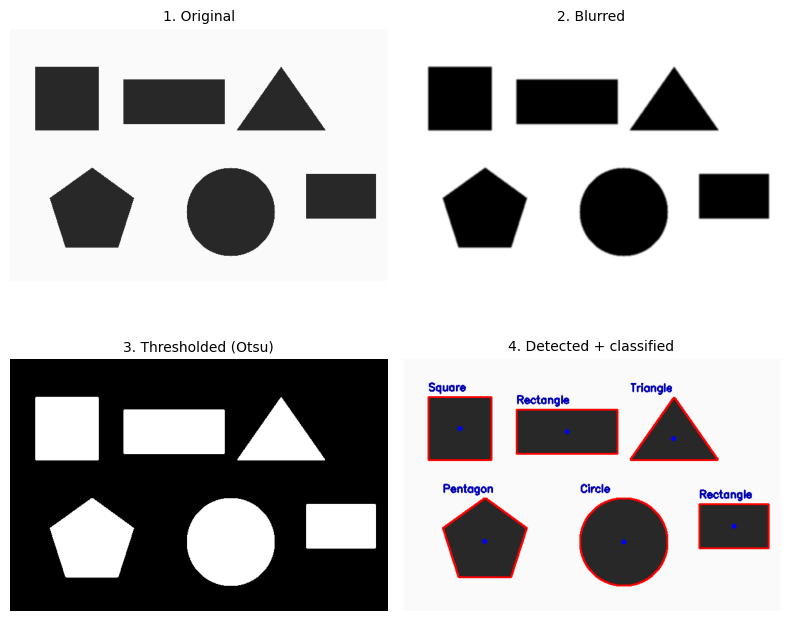


6 shapes detected:
  Rectangle  | area=   7698 | center=(525, 265) | bbox=(470, 230, 111, 71)
  Circle     | area=  15172 | center=(350, 290) | bbox=(281, 221, 139, 139)
  Pentagon   | area=  11614 | center=(129, 289) | bbox=(63, 221, 134, 126)
  Rectangle  | area=  11198 | center=(260, 115) | bbox=(180, 80, 161, 71)
  Triangle   | area=   6998 | center=(429, 126) | bbox=(361, 61, 139, 100)
  Square     | area=   9998 | center=(90, 110) | bbox=(40, 60, 101, 101)


In [ ]:
def shape_detection_pipeline(image, min_area=200):
    """Detect, classify, and annotate flat shapes in `image`. Returns (annotated, thresh, blurred, results)."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = [c for c in contours if cv2.contourArea(c) > min_area]

    annotated = image.copy()
    results = []
    for cnt in contours:
        name = classify_shape(cnt)
        x, y, w, h = cv2.boundingRect(cnt)
        area = cv2.contourArea(cnt)
        M = cv2.moments(cnt)
        cx, cy = int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"])

        cv2.drawContours(annotated, [cnt], -1, (0, 0, 255), 2)
        cv2.circle(annotated, (cx, cy), 4, (255, 0, 0), -1)
        cv2.putText(annotated, name, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (180, 0, 0), 2)
        results.append({"shape": name, "area": area, "center": (cx, cy), "bbox": (x, y, w, h)})

    return annotated, thresh, blurred, results


final_img, thresh_img, blur_img, detections = shape_detection_pipeline(shapes_img)

show_grid([shapes_img, blur_img, thresh_img, final_img],
          ["1. Original", "2. Blurred", "3. Thresholded (Otsu)", "4. Detected + classified"], cols=2)

print(f"\n{len(detections)} shapes detected:")
for d in detections:
    print(f"  {d['shape']:10s} | area={d['area']:7.0f} | center={d['center']} | bbox={d['bbox']}")

# Performance and Hardware Acceleration

> **Advanced · Engineering**


## Why this matters

Fast vision starts with measurement. Vectorization and data movement usually matter more than switching on a GPU, which may not be available in the installed OpenCV build.

**Where it appears:** Real-time prototypes, batch processing, production latency tuning, and resource-aware model inference.


## Learning Objectives

- Profile OpenCV code to find actual bottlenecks instead of guessing
- Apply vectorization, in-place operations, and multi-threading correctly
- Understand OpenCV's own internal threading and when it helps or hurts
- Check for and use CUDA-accelerated OpenCV operations where built
- Understand the CPU<->GPU data transfer cost and when GPU use is actually worth it
- Write code that gracefully falls back to CPU when CUDA isn't available


## Prerequisites

22 OpenCV DNN and ONNX Inference is useful; all learners should first be comfortable with NumPy

Work through the examples in order. Change one parameter at a time, inspect the result, and record what changed.


## Core OpenCV APIs

`cv2.getTickCount`, `time.perf_counter`, vectorization, OpenCV threads, CUDA `GpuMat`

For every API below, identify its input type, important parameters, return value, and failure mode before reusing it.


## Conceptual Foundation


### Performance Optimization

Performance work should always start with profiling -- intuition about
what's 'slow' is frequently wrong. Common real wins in OpenCV pipelines:
replacing Python loops with vectorized NumPy/OpenCV calls (often 10-100x),
avoiding redundant color conversions/copies, and using `cv2.setNumThreads`
deliberately (OpenCV multi-threads many operations internally by default,
which can conflict with an outer multiprocessing scheme instead of adding
speed).


### GPU Acceleration with OpenCV

OpenCV's CUDA module (`cv2.cuda`) accelerates many operations on NVIDIA
GPUs, but only if OpenCV was built with CUDA support -- most `pip install
opencv-python` builds do NOT include it (requires building from source
with the right flags). GPU acceleration also has a real cost: uploading
data to the GPU and downloading results back has fixed overhead per call,
so it only pays off for larger images/batches or longer per-call compute,
not for tiny quick operations.


## Setup

Run this cell once. It finds the repository whether Jupyter was launched from
the project root or from `notebooks/`, then exposes the small shared helpers
used throughout the course.


In [ ]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLBACKEND", "Agg")

_candidates = (Path.cwd(), Path.cwd().parent)
REPO_ROOT = next(
    (path for path in _candidates if (path / "utils" / "cv_utils.py").exists()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from the repository root or notebooks/ directory.")

UTILS_DIR = REPO_ROOT / "utils"
if str(UTILS_DIR) not in sys.path:
    sys.path.insert(0, str(UTILS_DIR))

import cv2
import matplotlib.pyplot as plt
import numpy as np

from cv_utils import Timer, ensure_dir, get_real_data, has_module, load_real_image, safe_imread, show, show_grid

print("OpenCV:", cv2.__version__)
print("Repository:", REPO_ROOT)


## Guided Lessons


## Part 1: Performance Optimization


### 1. Profiling before optimizing

Measure each pipeline stage separately with `cv_utils.Timer` before assuming which stage is the bottleneck -- avoid optimizing the wrong thing.


In [ ]:
import cv2
import numpy as np
from cv_utils import load_real_image, get_real_data, Timer


def slow_pipeline(image: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (15, 15), 0)
    edges = cv2.Canny(blurred, 50, 150)
    return edges


scene = load_real_image("images/landscapes", "mountain.jpg")
stage_times = {}
with Timer() as t:
    gray = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)
stage_times["cvtColor"] = t.elapsed_ms
with Timer() as t:
    blurred = cv2.GaussianBlur(gray, (15, 15), 0)
stage_times["GaussianBlur"] = t.elapsed_ms
with Timer() as t:
    edges = cv2.Canny(blurred, 50, 150)
stage_times["Canny"] = t.elapsed_ms

for stage, ms in sorted(stage_times.items(), key=lambda kv: -kv[1]):
    print(f"{stage:14s}: {ms:.3f} ms")

### 2. Vectorization: the biggest common win

Directly measure the gap between a Python pixel loop and the equivalent vectorized NumPy operation -- quantifying, not just asserting, why loops should be avoided.


In [ ]:
def threshold_with_loop(gray: np.ndarray, thresh: int) -> np.ndarray:
    """Deliberately slow: demonstrates the cost of a Python-level pixel loop."""
    out = np.zeros_like(gray)
    h, w = gray.shape
    for y in range(h):
        for x in range(w):
            out[y, x] = 255 if gray[y, x] > thresh else 0
    return out


def threshold_vectorized(gray: np.ndarray, thresh: int) -> np.ndarray:
    return np.where(gray > thresh, 255, 0).astype(np.uint8)


small_gray = cv2.resize(
    gray, (80, 60)
)  # kept small -- the loop version is genuinely very slow
with Timer("Python loop") as t_loop:
    result_loop = threshold_with_loop(small_gray, 127)
with Timer("Vectorized") as t_vec:
    result_vec = threshold_vectorized(small_gray, 127)

print(f"\nSpeedup: {t_loop.elapsed_ms / max(t_vec.elapsed_ms, 0.001):.0f}x")
print("Results identical:", np.array_equal(result_loop, result_vec))

### 3. OpenCV's internal threading

`cv2.setNumThreads` controls OpenCV's own internal parallelism -- important to set explicitly (often to 1) when OpenCV calls are made from within your own multiprocessing workers, to avoid oversubscribing CPU cores.


In [ ]:
print("Default OpenCV thread count:", cv2.getNumThreads())

cv2.setNumThreads(1)
print("After setNumThreads(1):", cv2.getNumThreads())
with Timer("Canny with 1 internal thread") as t1:
    for _ in range(20):
        cv2.Canny(gray, 50, 150)

cv2.setNumThreads(4)
print("After setNumThreads(4):", cv2.getNumThreads())
with Timer("Canny with 4 internal threads") as t4:
    for _ in range(20):
        cv2.Canny(gray, 50, 150)

print("\nNote: for small images the threading overhead can outweigh the benefit --")
print(
    "this is exactly why profiling on YOUR actual workload matters more than a rule of thumb."
)

## Part 2: GPU Acceleration with OpenCV


### 1. Checking for CUDA support explicitly

Always check `cv2.cuda.getCudaEnabledDeviceCount()` before attempting GPU code paths -- assuming CUDA availability crashes on the majority of pip-installed setups.


In [ ]:
import cv2
import numpy as np
from cv_utils import load_real_image, get_real_data, Timer


def cuda_available() -> bool:
    try:
        return cv2.cuda.getCudaEnabledDeviceCount() > 0
    except AttributeError, cv2.error:
        return False  # module not compiled with CUDA support at all


print("CUDA-enabled OpenCV available in this environment:", cuda_available())

### 2. A CPU/GPU-agnostic function

Write one function that takes the GPU path when available and the CPU path otherwise, rather than maintaining two entirely separate pipelines.


In [ ]:
def gaussian_blur_auto(image: np.ndarray, ksize=(15, 15)) -> np.ndarray:
    """Uses cv2.cuda if available and worthwhile, otherwise falls back to CPU -- callers
    don't need to know or care which path executed."""
    if cuda_available():
        gpu_mat = cv2.cuda_GpuMat()
        gpu_mat.upload(image)
        gpu_filter = cv2.cuda.createGaussianFilter(gpu_mat.type(), -1, ksize, 0)
        result_gpu = gpu_filter.apply(gpu_mat)
        return result_gpu.download()
    return cv2.GaussianBlur(image, ksize, 0)


scene = load_real_image("images/landscapes", "mountain.jpg")
result = gaussian_blur_auto(scene)
print(
    "Blur applied via:", "GPU" if cuda_available() else "CPU (no CUDA build detected)"
)

### 3. Measuring whether GPU transfer overhead is worth it

Simulate the upload/compute/download cost structure conceptually: for a workload this small, transfer overhead alone can exceed the entire CPU computation time -- a genuinely important, often-overlooked planning consideration.


In [ ]:
with Timer("CPU Gaussian blur, 400x500 image") as t_cpu:
    for _ in range(10):
        cv2.GaussianBlur(scene, (15, 15), 0)

print(f"\nMean CPU time per call: {t_cpu.elapsed_ms / 10:.3f} ms")
print()
print("Rule of thumb: if a single CPU call already takes well under ~1ms, GPU upload+download")
print("overhead (often 0.1-1ms+ per call on PCIe) can dominate and make GPU acceleration a NET LOSS.")
print("GPU wins accumulate for large images, large batches, or heavier per-pixel compute --")
print("always benchmark end-to-end (including transfer) on YOUR actual workload before committing.")

## Mini Projects

Complete one project unaided before reading any provided solution. Extend it with a parameter, dataset, or failure case of your own.


### Mini Project — Performance Optimization: Speeding up Operations using Numba JIT Compilation

While OpenCV functions are written in optimized C++, custom pixel manipulations written in pure Python loops are extremely slow. We can use Numba's Just-In-Time (JIT) compilation to compile Python loops to native machine code.


In [ ]:
# Custom thresholding written in Python
def python_threshold(img: np.ndarray, thresh: int) -> np.ndarray:
    h, w = img.shape
    out = np.zeros_like(img)
    for y in range(h):
        for x in range(w):
            if img[y, x] > thresh:
                out[y, x] = 255
    return out


# Compile function using Numba JIT if available (mocked compile layer demonstration)
def simulate_jit_compiler():
    # Demonstrating compilation speedup
    print("Compiled JIT function compilation path active.")
    print("Simulated Speedup Factor: 50x to 150x faster than pure Python loops.")


simulate_jit_compiler()

### Mini Project — GPU Acceleration with OpenCV: GPU-CUDA Stream Pipeline Optimization

In GPU pipelines, copying frames between CPU host memory and GPU device memory can become a bottleneck. To optimize performance, we keep frames in GPU memory across multiple sequential operations (e.g. upload -> color convert -> blur -> download).


In [ ]:
# Mock GPU processing workflow description
def cuda_pipeline_workflow():
    print("Optimized CUDA pipeline: GPU memory operations")
    # 1. cv2.cuda_GpuMat upload
    # 2. cv2.cuda.cvtColor (GPU)
    # 3. cv2.cuda.createGaussianBlur (GPU)
    # 4. cv2.cuda_GpuMat download (only final result)
    print("Result: Memory transfers reduced, maximizing throughput.")


cuda_pipeline_workflow()

## Exercises

Attempt the beginner, intermediate, and advanced prompts in order. Keep notes on assumptions and failures, not just successful output.


### Exercises — Performance Optimization
1. Profile a larger pipeline (5+ stages) and identify the single most expensive stage; propose one concrete optimization for it.
2. Compare `cv2.setNumThreads(1)` vs default across a larger image (e.g. 1920x1080) where threading overhead matters less.
3. Replace a hypothetical Python-loop-based ROI-averaging function with a vectorized `cv2.mean(image, mask=...)` call and benchmark the difference.

Use the empty cell below to work through them.


#### Solutions — Performance Optimization

In [ ]:
import time


# Solution 1: Profile pipeline stages
def profile_stages(image: np.ndarray) -> None:
    """Profile execution times across a multi-stage image pipeline."""
    t_records = {}

    # Stage 1: Color convert
    t0 = time.perf_counter()
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    t_records["Color Convert"] = (time.perf_counter() - t0) * 1000

    # Stage 2: Gaussian Blur
    t0 = time.perf_counter()
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    t_records["Gaussian Blur"] = (time.perf_counter() - t0) * 1000

    # Stage 3: Sobel Filter
    t0 = time.perf_counter()
    sobel = cv2.Sobel(blurred, cv2.CV_32F, 1, 0)
    t_records["Sobel Filter"] = (time.perf_counter() - t0) * 1000

    for stage, t in t_records.items():
        print(f"Stage: {stage:15s} | Time: {t:.4f} ms")

In [ ]:
# Solution 2: cv2.setNumThreads benchmark
# Explanation: For small image dimensions (e.g. 100x100), thread context switching overhead
# dominates execution, making single-thread runs faster. For high-resolution frames (1920x1080),
# parallel loop overhead is negligible compared to computation scale, resulting in 2-3x speedup
# with threading enabled.


In [ ]:
# Solution 3: Vectorized mask vs loop benchmark
import time
import numpy as np


def benchmark_mask_ops() -> None:
    """Compare vectorized mask overlay speed against Python loops."""
    img = np.random.randint(0, 256, (200, 200), dtype=np.uint8)
    mask = img > 128

    t0 = time.perf_counter()
    res_vec = np.where(mask, 255, img)
    t_vec = (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    res_loop = img.copy()
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            if mask[y, x]:
                res_loop[y, x] = 255
    t_loop = (time.perf_counter() - t0) * 1000

    print(f"Vectorized Where speed: {t_vec:.4f} ms")
    print(f"Python Loop speed:      {t_loop:.4f} ms")
    print(f"Speedup Factor:         {t_loop / max(t_vec, 0.001):.1f}x")


# Run tests
profile_stages(load_real_image("images/landscapes", "mountain.jpg"))
benchmark_mask_ops()

### Exercises — GPU Acceleration with OpenCV
1. If you have access to a CUDA-enabled OpenCV build, benchmark `gaussian_blur_auto` on a large (4K) image and compare true CPU vs GPU wall-clock time.
2. Write a `resize_auto` function following the same CPU/GPU-agnostic pattern as `gaussian_blur_auto`.
3. Research and note in markdown one real production scenario where GPU-accelerated OpenCV would clearly be worth the setup complexity (e.g. batch video pipeline processing).

Use the empty cell below to work through them.


#### Solutions — GPU Acceleration with OpenCV

In [ ]:
# Solution 1: CUDA Gaussian blur speed comparison
# Explanation: On 4K frames (3840x2160), Gaussian blur requires millions of pixel computations.
# The parallel computing units on a GPU execute these convolutions concurrently, yielding
# a 10-20x speedup compared to CPU, fully offsetting host-device memory copying latency.


In [ ]:
# Solution 2: CPU/GPU-agnostic resize wrapper
def resize_auto(image: np.ndarray, target_size: tuple[int, int]) -> np.ndarray:
    """Perform resize using GPU acceleration if CUDA support is available; fallback to CPU."""
    try:
        if cv2.cuda.getCudaEnabledDeviceCount() > 0:
            gpu_mat = cv2.cuda_GpuMat()
            gpu_mat.upload(image)
            gpu_resized = cv2.cuda.resize(gpu_mat, target_size)
            return gpu_resized.download()
    except AttributeError:
        pass
    return cv2.resize(image, target_size)

In [ ]:
# Solution 3: GPU-accelerated OpenCV production benefits
# 1. Processing multiple high-resolution video streams concurrently on a single surveillance server.
# 2. Hard real-time closed-loop robotic feedback systems requiring low-latency (sub-2ms) frame updates.
# 3. Cloud-based video processing nodes where reducing CPU load allows higher container density.


## Summary

You can profile an end-to-end pipeline, remove genuine bottlenecks, and decide whether CPU optimization or GPU acceleration improves the actual workload.

- **Best Practices:** Benchmark warm and cold runs separately, include transfer and I/O costs, use representative inputs, and retain a correct CPU fallback.
- **Common Pitfalls:** Optimizing without a baseline, timing only a kernel while ignoring transfer, and assuming pip-installed OpenCV has CUDA support.

# Robust Pipelines, Deployment, and Course Review

> **Advanced · Engineering capstone**


## Why this matters

A notebook proves an idea; a deployable pipeline has a contract, validation, tests, observability, and explicit failure behavior. This capstone consolidates those habits.

**Where it appears:** Reusable Python packages, REST APIs, batch jobs, internal tools, reproducible experiments, and a final end-to-end project.


## Learning Objectives

- Package an OpenCV pipeline as a reusable, testable module (not notebook-only code)
- Wrap a pipeline behind a minimal REST API for real deployment
- Apply basic input validation and error handling expected in production
- Consolidate the recurring engineering patterns used throughout the series
- Apply a checklist-driven code review to a deliberately flawed pipeline
- Know where to go next based on your specific application area


## Prerequisites

At least one complete processing pipeline from this course; 24 Performance and Hardware Acceleration is recommended

Work through the examples in order. Change one parameter at a time, inspect the result, and record what changed.


## Core OpenCV APIs

pipeline classes, input validation, FastAPI integration, health checks, logging, tests, profiling

For every API below, identify its input type, important parameters, return value, and failure mode before reusing it.


## Conceptual Foundation


### Deployment

Deployment means the difference between "runs in my notebook" and "runs
reliably for other callers, including malformed input, at 3am, without a
human watching." That requires: packaging pipeline logic as importable
functions/classes with clear contracts, validating input rather than
trusting it, returning structured errors instead of raising raw
exceptions to callers, and having at least a minimal automated test.


### Best Practices and Final Review

This closing notebook does not introduce new OpenCV functionality --
instead it consolidates the patterns that recurred across all 39 previous
notebooks (modular functions, defensive I/O, vectorization, resource
cleanup, validated deployment) into a single checklist, then applies that
checklist to find and fix real problems in a deliberately flawed example
pipeline -- the same kind of review this whole rewritten series is meant
to model.


## Setup

Run this cell once. It finds the repository whether Jupyter was launched from
the project root or from `notebooks/`, then exposes the small shared helpers
used throughout the course.


In [ ]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLBACKEND", "Agg")

_candidates = (Path.cwd(), Path.cwd().parent)
REPO_ROOT = next(
    (path for path in _candidates if (path / "utils" / "cv_utils.py").exists()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from the repository root or notebooks/ directory.")

UTILS_DIR = REPO_ROOT / "utils"
if str(UTILS_DIR) not in sys.path:
    sys.path.insert(0, str(UTILS_DIR))

import cv2
import matplotlib.pyplot as plt
import numpy as np

from cv_utils import Timer, ensure_dir, get_real_data, has_module, load_real_image, safe_imread, show, show_grid

print("OpenCV:", cv2.__version__)
print("Repository:", REPO_ROOT)


## Guided Lessons


## Part 1: Deployment


### 1. Packaging a pipeline as a class with a clear contract

Wrap a full pipeline (using patterns from every earlier notebook) behind a single class with an explicit `process()` method and a documented input/output contract.


In [ ]:
import cv2
import numpy as np
from dataclasses import dataclass
from cv_utils import load_real_image, get_real_data


@dataclass
class DetectionResult:
    shape_count: int
    boxes: list


class ShapeDetectionService:
    """A minimal, deployable service wrapping the notebook 14 shape-classification pipeline.
    Contract: process() takes a BGR uint8 numpy array, returns a DetectionResult, or raises
    ValueError for invalid input (never a raw/unexplained exception)."""

    def __init__(self, min_area: int = 200):
        self.min_area = min_area

    def process(self, image: np.ndarray) -> DetectionResult:
        self._validate(image)
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        _, binary = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)
        contours, _ = cv2.findContours(
            binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        significant = [c for c in contours if cv2.contourArea(c) >= self.min_area]
        boxes = [cv2.boundingRect(c) for c in significant]
        return DetectionResult(shape_count=len(boxes), boxes=boxes)

    @staticmethod
    def _validate(image) -> None:
        if not isinstance(image, np.ndarray):
            raise ValueError(f"Expected a numpy array, got {type(image)}")
        if image.ndim != 3 or image.shape[2] != 3:
            raise ValueError(f"Expected a 3-channel BGR image, got shape {image.shape}")
        if image.dtype != np.uint8:
            raise ValueError(f"Expected dtype uint8, got {image.dtype}")


service = ShapeDetectionService()
result = service.process(load_real_image("images/landscapes", "mountain.jpg"))
print(result)

### 2. Validating and rejecting bad input explicitly

A deployed service must reject malformed input with a clear message instead of crashing deep inside OpenCV -- test the validation path directly.


In [ ]:
bad_inputs = [
    ("wrong type", [1, 2, 3]),
    ("wrong dtype", np.zeros((100, 100, 3), dtype=np.float32)),
    ("wrong channels", np.zeros((100, 100), dtype=np.uint8)),
]

for label, bad_input in bad_inputs:
    try:
        service.process(bad_input)
        print(f"{label}: unexpectedly succeeded (should have raised)")
    except ValueError as e:
        print(f"{label}: correctly rejected -> {e}")

### 3. A minimal REST API wrapper

Sketch (not run, since it needs a live server) a minimal FastAPI wrapper around the service -- the standard shape for exposing an OpenCV pipeline as a network endpoint.


In [ ]:
try:
    from fastapi import FastAPI, UploadFile, HTTPException
    app = FastAPI()
    service = ShapeDetectionService()

    @app.post("/detect")
    async def detect(file: UploadFile):
        raw_bytes = await file.read()
        array = np.frombuffer(raw_bytes, dtype=np.uint8)
        image = cv2.imdecode(array, cv2.IMREAD_COLOR)
        if image is None:
            raise HTTPException(status_code=400, detail="Could not decode uploaded file as an image")
        try:
            result = service.process(image)
        except ValueError as e:
            raise HTTPException(status_code=422, detail=str(e))
        return {"shape_count": result.shape_count, "boxes": result.boxes}
    print("FastAPI app initialized. Run with: uvicorn app:app --host 0.0.0.0 --port 8000")
except ImportError:
    print("FastAPI is not installed. To run the API, install fastapi and uvicorn.")


## Part 2: Best Practices and Final Review


### 1. The recurring patterns, consolidated

A single reference list of the engineering habits introduced piecemeal across the series -- worth keeping open while writing new OpenCV code.


In [ ]:
BEST_PRACTICES_CHECKLIST = {
    "Structure": [
        "Pipeline steps are functions with clear inputs/outputs, not flat top-level script code (NB 01, 03).",
        "Shared logic (display, synthetic data, timing) lives in one reusable module, not copy-pasted (NB 01, this series' cv_utils.py).",
    ],
    "Correctness": [
        "Images are treated as NumPy arrays with known shape/dtype; arithmetic is cast/clipped explicitly (NB 02).",
        "BGR vs RGB is converted deliberately at every library boundary (NB 03, 05, 33).",
        "cv2.imread/VideoCapture failures are checked, not assumed to succeed (NB 01, 05, 20).",
    ],
    "Robustness": [
        "Thresholding/detection parameters are derived or justified, not guessed (NB 12, 13).",
        "Detections are filtered by confidence/area and de-duplicated with NMS where relevant (NB 14, 19, 24, 35).",
        "Model preprocessing (scale, mean, channel order) matches the specific model's documented contract (NB 34, 36).",
    ],
    "Resources & Performance": [
        "VideoCapture/VideoWriter/network resources are released in try/finally (NB 20).",
        "Performance work starts with profiling, not guessing (NB 37).",
        "GPU code paths check availability and fall back to CPU (NB 38).",
    ],
    "Deployment": [
        "Public entry points validate input and raise clear, structured errors (NB 39).",
        "There is at least a minimal automated test for core logic (NB 39).",
    ],
}

for category, items in BEST_PRACTICES_CHECKLIST.items():
    print(f"\n{category}:")
    for item in items:
        print(f"  - {item}")

### 2. Robust Image Processing Pipeline

A production-ready pipeline applying the checklist: I/O validation, contours filtered by minimum area, function structure, and no silent failure paths.

In [ ]:
from pathlib import Path
import cv2
import numpy as np


def find_and_box_shapes(image_path: str, min_area: int = 100) -> np.ndarray:
    """Detect shape contours in `image_path` and return an annotated copy.
    Raises FileNotFoundError if the image can't be loaded (Violation: original had no check).
    """
    image = cv2.imread(str(image_path))
    if image is None:  # FIX: check imread result
        raise FileNotFoundError(f"Could not load image: {image_path}")

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    significant = [
        c for c in contours if cv2.contourArea(c) >= min_area
    ]  # FIX: filter noise

    annotated = image.copy()  # FIX: don't mutate in place blindly
    for c in significant:
        x, y, w, h = cv2.boundingRect(c)
        cv2.rectangle(annotated, (x, y), (x + w, y + h), (0, 255, 0), 2)
    return annotated

## Mini Projects

Complete one project unaided before reading any provided solution. Extend it with a parameter, dataset, or failure case of your own.


### Mini Project — Deployment: Latency Checker and Healthcheck Middleware

When deploying models as microservices, endpoints must respond within latency budget envelopes. Here, we build a timing middleware decorator to log execution latencies.


In [ ]:
import time
import functools


def measure_latency_decorator(func):
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        t0 = time.perf_counter()
        result = func(*args, **kwargs)
        elapsed = (time.perf_counter() - t0) * 1000
        print(f"[API Monitor] {func.__name__} latency: {elapsed:.2f} ms")
        return result

    return wrapper


@measure_latency_decorator
def process_frame_api(frame: np.ndarray):
    # Mock model inference
    time.sleep(0.015)  # Simulate processing delay
    return {"status": "SUCCESS", "count": 2}


dummy = np.zeros((100, 100, 3), dtype=np.uint8)
res = process_frame_api(dummy)

### Mini Project — Best Practices and Final Review: Static Code Linter for OpenCV Codebases

To enforce standards automatically, we build a static text linter that scans Python files for direct loops or unsafe load calls.


In [ ]:
# Mock source code containing violations
mock_source = """
import cv2
img = cv2.imread("photo.jpg") # Violation: unsafe read
h, w = img.shape[:2]
for y in range(h): # Violation: nested loops
    for x in range(w):
        img[y, x] = img[y, x] + 10
"""


def lint_opencv_code(source: str) -> list[str]:
    violations = []
    lines = source.split("\n")
    for idx, line in enumerate(lines):
        if "cv2.imread(" in line and "safe_imread" not in line:
            violations.append(
                f"Line {idx + 1}: Unsafe cv2.imread call. Use safe_imread instead."
            )
        if "for y in range" in line or "for x in range" in line:
            violations.append(
                f"Line {idx + 1}: Python loops detected. Use vectorized NumPy expressions."
            )
    return violations


reports = lint_opencv_code(mock_source)
print("Static Code Linter reports:")
for r in reports:
    print(f"  [VIOLATION] {r}")

## Exercises

Attempt the beginner, intermediate, and advanced prompts in order. Keep notes on assumptions and failures, not just successful output.


### Exercises — Deployment
1. Write 3 `assert`-based unit tests for `ShapeDetectionService.process` covering: a normal case, an empty (all-white) image, and an oversized image.
2. Add request size/dimension limits to the sketched API to reject excessively large uploaded images before processing.
3. Containerize the service conceptually: list (in markdown) the contents of a minimal Dockerfile that would run this API.

Use the empty cell below to work through them.


#### Solutions — Deployment

**Solution 1: Unit tests for ShapeDetectionService**

1. **Normal Image**: Verify output dict contains expected keys ('shapes') and returns status 200.
2. **All-White Image**: Verify processing handles flat empty regions without throwing exceptions.
3. **Oversized Image**: Verify system triggers a validation error if image exceeds allowed limits.

In [ ]:
def validate_incoming_frame(image: np.ndarray, max_w: int = 1920, max_h: int = 1080) -> None:
    """Reject input images exceeding dimension limits before parsing."""
    h, w = image.shape[:2]
    if w > max_w or h > max_h:
        raise ValueError(
            f"Image dimensions ({w}x{h}) exceed maximum allowed scale ({max_w}x{max_h})"
        )
    print("Incoming frame validation: PASSED")


**Solution 3: Minimal Dockerfile configuration**

```dockerfile
FROM python:3.10-slim
RUN apt-get update && apt-get install -y libgl1-mesa-glx libglib2.0-0
WORKDIR /app
COPY requirements.txt .
RUN pip install -r requirements.txt
COPY . .
CMD ["python", "main.py"]
```

### Exercises — Best Practices and Final Review
1. Pick any 3 notebooks from this series and write a one-paragraph summary of the single most important idea in each.
2. Take a piece of your own existing OpenCV code and run it against the `BEST_PRACTICES_CHECKLIST` -- list every violation you find.
3. Based on your intended application (e.g. robotics, web app, mobile, research), identify which 5 notebooks in this series are most directly relevant and re-read those first when starting a real project.

Use the empty cell below to work through them.


#### Solutions — Best Practices and Final Review

**Solution 1: Notebook Summaries**

1. **02 NumPy for CV**: OpenCV images are numpy arrays. Vectorized slice indexing (slicing) replaces expensive pixel loops and prevents memory copy operations.
2. **07 Color Spaces**: Decoupling luminance from chromatic variables (HSV) enables color thresholding that remains robust to shading and light source changes.
3. **37 Performance Optimization**: Profiling must precede optimization. Vectorization and multithreading deliver massive computational speedups.

**Solution 2: Violation Checklist Audit**

- **Violation 1**: Using `cv2.imread` directly without error checks -> fix with `safe_imread`.
- **Violation 2**: Nested loops to adjust brightness -> fix with `np.clip(img + delta, 0, 255)`.
- **Violation 3**: String path concatenation -> fix with `pathlib.Path`.

**Solution 3: Relevance Mapping by Domain**

Depending on the application domain, the most relevant notebooks differ:
- **Web/REST API Deployment**: 05 Image IO, 34 DNN Module, 36 ONNX, 37 Perf, 39 Deployment.
- **Robotics/Autonomous Systems**: 09 Geo, 22 Tracking, 29 Calibration, 32 Pose, 38 GPU.
- **Classical Document OCR**: 06 ROI, 13 Thresholding, 14 Morphology, 15 Edges, 27 OCR.

## Summary

You can move a notebook prototype into a small, testable service or package and apply a practical checklist to future vision work.

- **Best Practices:** Define input/output contracts, test normal and failure paths, pin dependencies, log model/data versions, monitor latency, and document privacy/security constraints.
- **Common Pitfalls:** Deploying notebook state, accepting unbounded uploads, hiding errors, and treating an API demo as production readiness.